# Foundation ePSF head visualisation

Visual + quantitative check on the production PSF model. Section ordering
matters: **the Gaia rebuild preflight comes first** — if the build pipeline
is not selecting and centring real stars, every downstream PSF metric is
meaningless no matter how it is computed.

Sections:

1. Gaia rebuild preflight — per-band counts / SNR / source_id presence.
2. Sanity check — same source across all bands (is the build picking real
   isolated point sources?).
3. Empirical per-band ePSF baseline — no NN, no spatial variation.
4. Load FoundationEPSFHead — checkpoint config, demo tile encoding,
   field-centre ePSFs.
5. Per-band predicted ePSF at field centre (log scale, core σ in title).
6. Radial profile per band.
7. Held-out validation — Pearson r and chi^2/dof per band.
8. Empirical-base vs NN residual-head comparison.

In [14]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "io" else Path.cwd()
sys.path.insert(0, str(ROOT / "models"))

TRAIN_DIR = ROOT / "data/psf_training_gaia_pm_v2"
HEAD_CKPT = ROOT / "models/checkpoints/foundation_epsf_head_empirical_r15_centroid1px_satfix_v1/checkpoint_best.pt"


ALL_BANDS = [
    "rubin_u", "rubin_g", "rubin_r", "rubin_i", "rubin_z", "rubin_y",
    "euclid_VIS", "euclid_Y", "euclid_J", "euclid_H",
]
PCA_BANDS = list(ALL_BANDS)
PCA_PX_NATIVE = {b: 0.2 if b.startswith("rubin") else 0.1 for b in ALL_BANDS}

## 1. Gaia rebuild preflight

Run these checks on a freshly rebuilt Gaia training set **before** retraining the PSF head.

What to verify:

1. All expected band files exist and carry `source_id`.
2. The same Gaia source looks consistently centred across `rubin_r/i/z` and `euclid_VIS/Y/J/H`.
3. The centroid residual summary is improved, especially in the higher-S/N bands.


TRAIN_DIR = /home/shemmati/Work/Projects/JAISP/data/psf_training_gaia_pm_v2
band               n  snr_med  source_id
rubin_u          822     75.2       True
rubin_g          971   1695.6       True
rubin_r          971   2866.7       True
rubin_i          973   3249.4       True
rubin_z          973   2655.3       True
rubin_y          973    575.9       True
euclid_VIS      1100    560.6       True
euclid_Y        1068    219.2       True
euclid_J        1049    240.6       True
euclid_H        1053    237.3       True


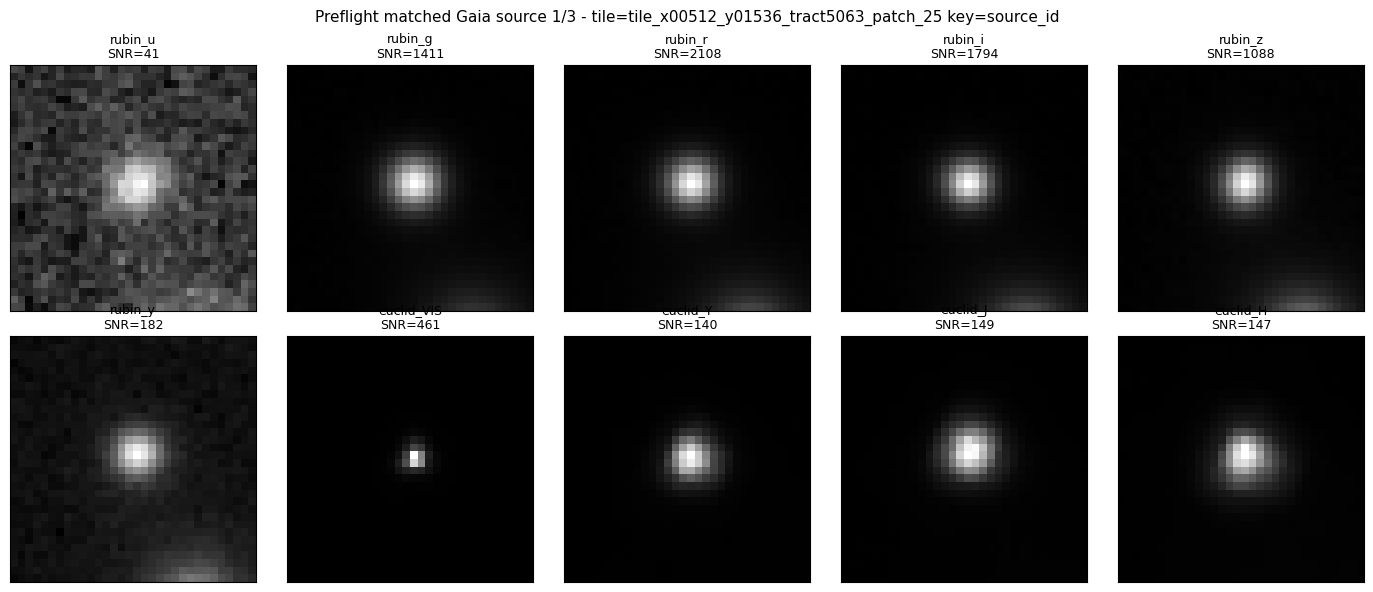

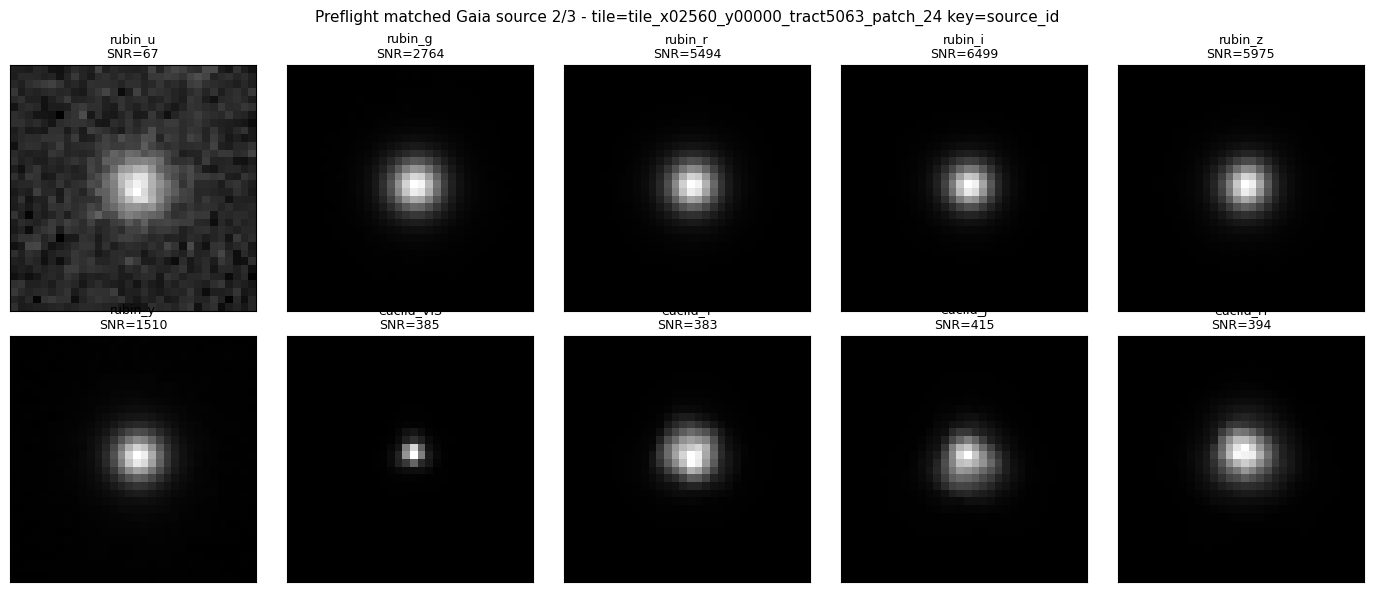

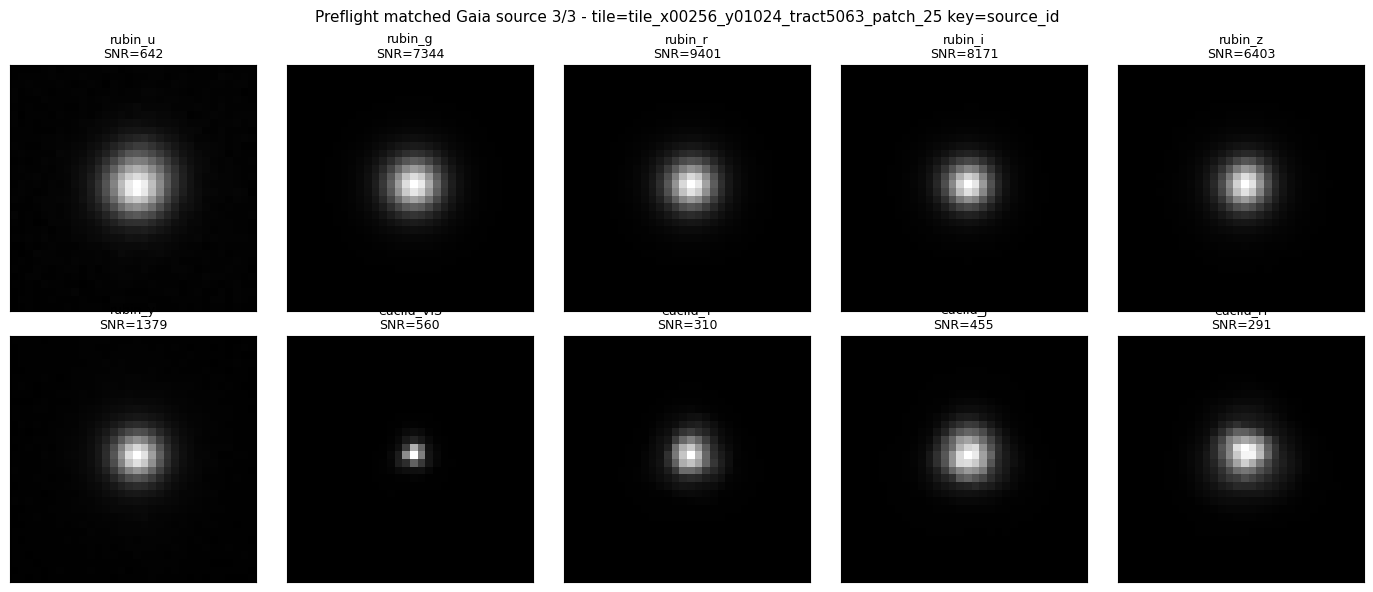


band        median_dx  median_dy   median_r
rubin_r        -0.024      0.029      0.068
rubin_i        -0.033      0.039      0.074
rubin_z        -0.021     -0.011      0.057
euclid_VIS     -0.001      0.010      0.022
euclid_Y        0.025      0.012      0.140
euclid_J        0.033     -0.005      0.127
euclid_H        0.034      0.005      0.141


In [2]:
ANCHOR_BAND = "rubin_r"
N_PREFLIGHT = 3
SEED = 42

def _match_source(d, tile, key_name, key_value):
    tile_match = d["tile_id"] == tile
    if key_name in d.files:
        if key_name == "source_id":
            return tile_match & (d[key_name] == key_value)
        return tile_match & (np.abs(d[key_name] - float(key_value)) < 1e-3)
    return np.zeros(d["tile_id"].shape, dtype=bool)

def _centroid_residual(stamp, frac_xy, ap_radius=5.0):
    s = np.asarray(stamp, dtype=np.float64)
    S = s.shape[-1]
    yy, xx = np.indices(s.shape, dtype=np.float64)
    tx = S // 2 + float(frac_xy[0])
    ty = S // 2 + float(frac_xy[1])
    r = np.hypot(xx - tx, yy - ty)
    bg_mask = r > min(14.0, S * 0.38)
    bg = float(np.nanmedian(s[bg_mask])) if bg_mask.any() else float(np.nanmedian(s))
    w = np.clip(s - bg, 0.0, None) * (r < ap_radius)
    total = float(w.sum())
    if total <= 0:
        return np.nan, np.nan, np.nan
    cx = float((xx * w).sum() / total)
    cy = float((yy * w).sum() / total)
    dx = cx - tx
    dy = cy - ty
    return dx, dy, float(np.hypot(dx, dy))

band_data = {}
print(f"TRAIN_DIR = {TRAIN_DIR}")
print(f"{'band':12s} {'n':>7s} {'snr_med':>8s} {'source_id':>10s}")
for band in ALL_BANDS:
    p = TRAIN_DIR / f"{band}.npz"
    if not p.exists():
        band_data[band] = None
        print(f"{band:12s} {'missing':>7s} {'-':>8s} {'-':>10s}")
        continue
    d = np.load(p, allow_pickle=False)
    band_data[band] = d
    n = int(d['stamps'].shape[0])
    snr_med = float(np.nanmedian(d['snr'])) if n > 0 else float('nan')
    has_sid = 'source_id' in d.files
    print(f"{band:12s} {n:7d} {snr_med:8.1f} {str(has_sid):>10s}")

d_anchor = band_data[ANCHOR_BAND]
if d_anchor is None:
    raise FileNotFoundError(f"Missing anchor band file for {ANCHOR_BAND}: {TRAIN_DIR / (ANCHOR_BAND + '.npz')}")
match_key = 'source_id' if 'source_id' in d_anchor.files else 'g_mag'
rng = np.random.RandomState(SEED)
n_pick = min(N_PREFLIGHT, int(d_anchor['stamps'].shape[0]))
anchor_idx = rng.choice(d_anchor['stamps'].shape[0], n_pick, replace=False)

for trial, idx in enumerate(anchor_idx, start=1):
    tile = d_anchor['tile_id'][idx]
    key_value = d_anchor[match_key][idx]
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    for ax, band in zip(axes.flat, ALL_BANDS):
        d = band_data.get(band)
        ax.set_xticks([])
        ax.set_yticks([])
        if d is None or match_key not in d.files:
            ax.set_facecolor('#cccccc')
            ax.set_title(f"{band}\nmissing", fontsize=9)
            continue
        m = _match_source(d, tile, match_key, key_value)
        if not m.any():
            ax.set_facecolor('#cccccc')
            ax.set_title(f"{band}\nmissing", fontsize=9)
            continue
        j = int(np.where(m)[0][0])
        s = d['stamps'][j]
        ax.imshow(s, origin='lower', cmap='gray')
        ax.set_title(f"{band}\nSNR={float(d['snr'][j]):.0f}", fontsize=9)
    fig.suptitle(f"Preflight matched Gaia source {trial}/{n_pick} - tile={tile} key={match_key}", fontsize=11)
    plt.tight_layout()
    plt.show()

print()
print(f"{'band':10s} {'median_dx':>10s} {'median_dy':>10s} {'median_r':>10s}")
for band in ['rubin_r', 'rubin_i', 'rubin_z', 'euclid_VIS', 'euclid_Y', 'euclid_J', 'euclid_H']:
    d = band_data.get(band)
    if d is None:
        continue
    S = d['stamps'].shape[-1]
    dxs, dys = [], []
    n_eval = min(2000, int(d['stamps'].shape[0]))
    for stamp, frac in zip(d['stamps'][:n_eval], d['frac_xy'][:n_eval]):
        dx, dy, dr = _centroid_residual(stamp, frac)
        if np.isfinite(dr):
            dxs.append(dx)
            dys.append(dy)
    if not dxs:
        continue
    dxs = np.asarray(dxs)
    dys = np.asarray(dys)
    print(f"{band:10s} {np.median(dxs):10.3f} {np.median(dys):10.3f} {np.median(np.hypot(dxs, dys)):10.3f}")


## 2. Sanity check — same source across all bands (GAIA-anchored)

Stamps are now built from **GAIA DR3 stars** (sub-mas RA/Dec, confirmed point sources via parallax / proper motion / single-source flags) instead of CenterNet detections. Each band's WCS projects (RA, Dec) → pixel coords directly, eliminating the bogus VIS-to-Rubin half-pixel scaling that caused the previous off-centre stamps.

This cell picks 10 random GAIA-anchored sources present in **all 10 band files** by default, then shows the matched stamp in every band.

**What to look for:** clean centred star-like cores in every panel. With GAIA you should see this — if you don't, the build pipeline still has a bug.

Set `REQUIRE_ALL_BANDS = False` to inspect missing-band cases. Empty grey panels then mean the same `(tile_id, source_id)` is not in that band's npz, usually because that band failed the per-band SNR / centroid / edge filters. SNR is labelled in red.

Build:
```
PYTHONPATH=models python models/psf/build_psf_gaia_training_set.py \
    --rubin-dir   data/rubin_tiles_all \
    --euclid-dir  data/euclid_tiles_all \
    --out-dir     data/psf_training_gaia_pm_v2 \
    --stamp-size  32 \
    --max-centroid-resid-px 1.0
```


All-band complete source/tile pairs: 716
NISP completeness: Y&J&H=1004  Y&J not H=22  Y&H not J=28  J&H not Y=17
Anchor pool after all-band requirement: 716 / 971


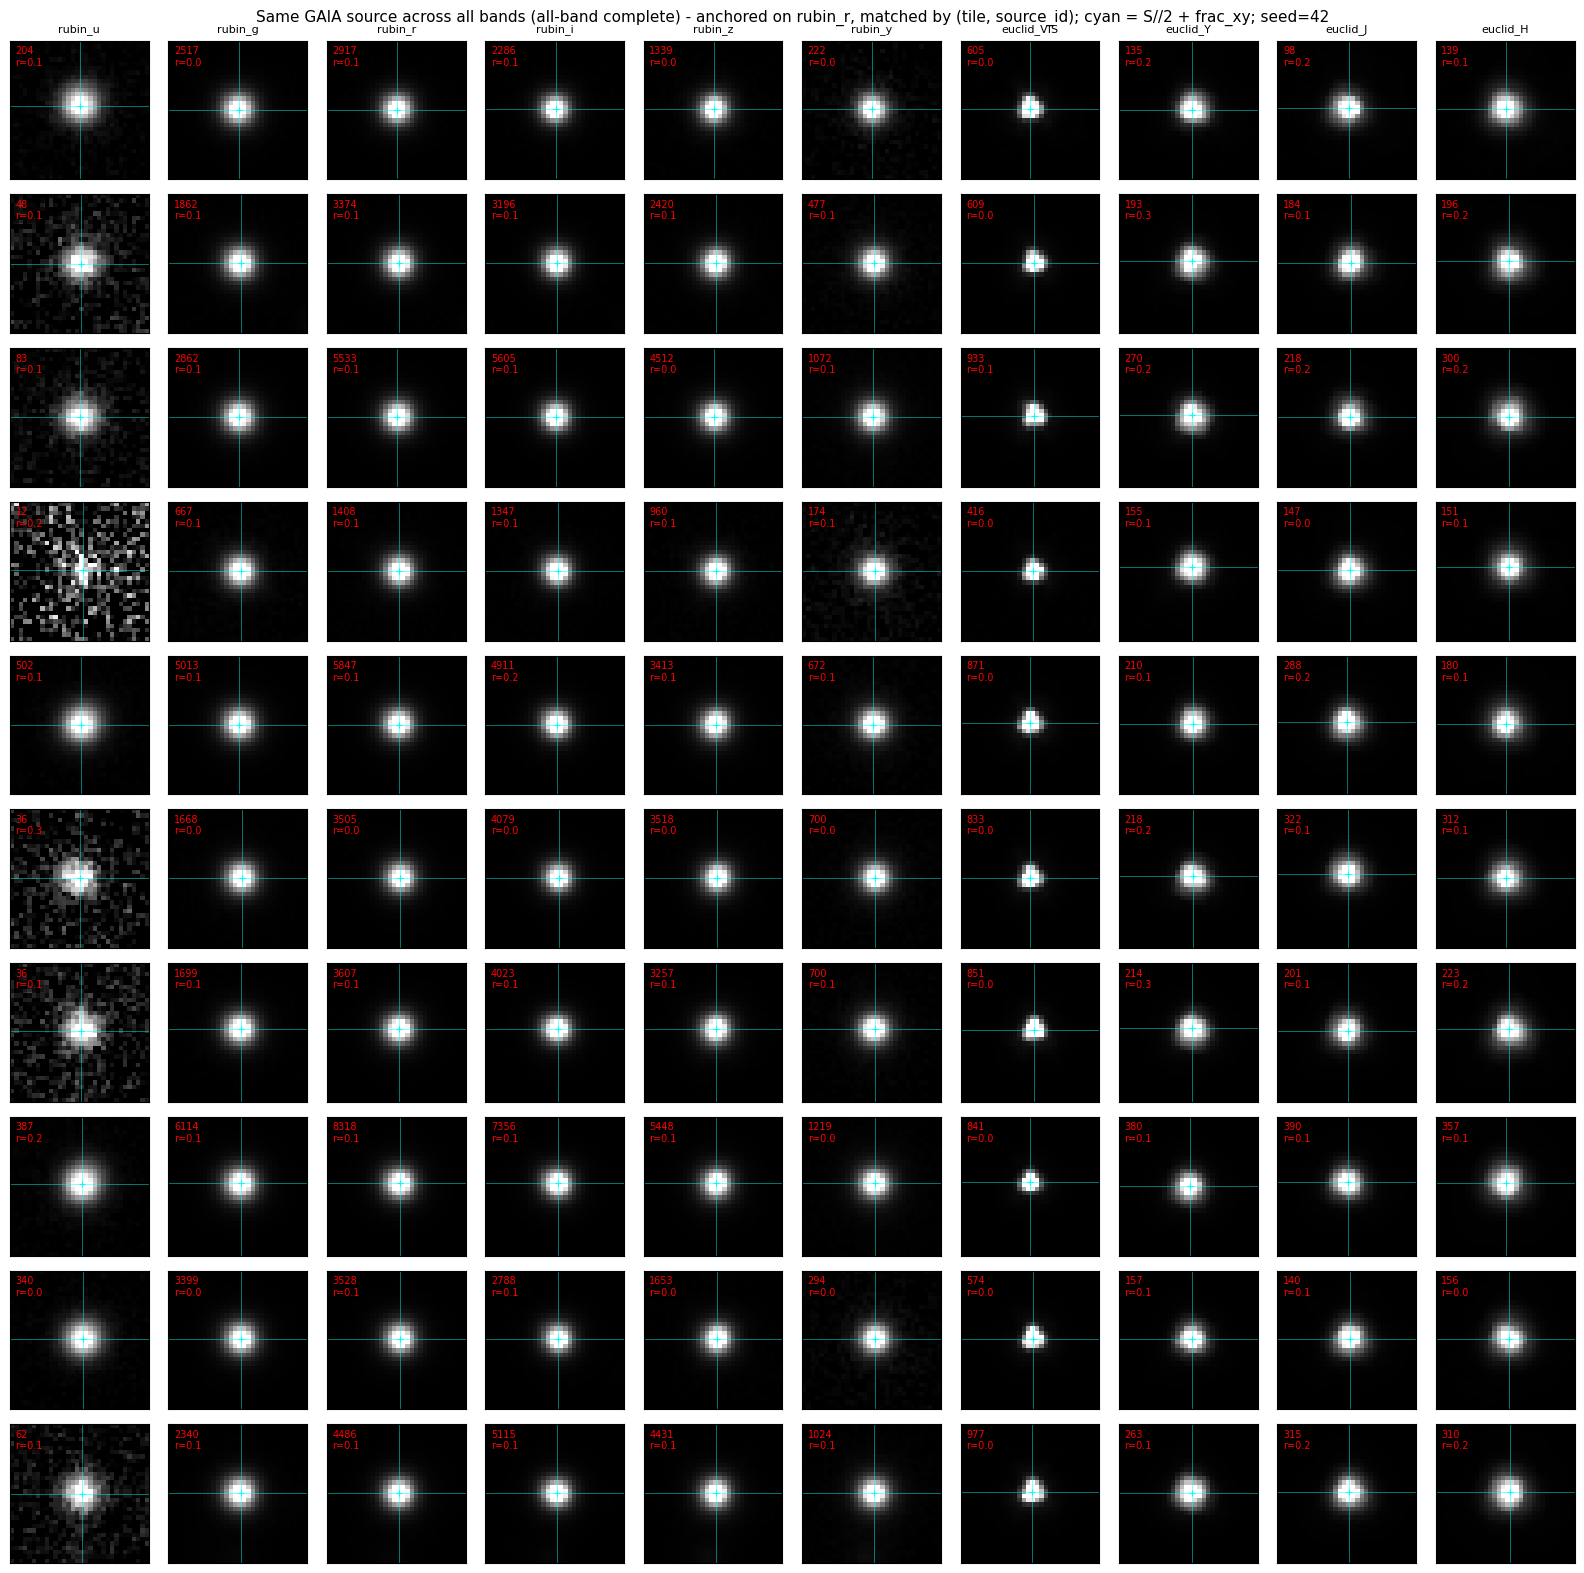

band             n median_r_px  p90_r_px  max_r_px
rubin_u         10       0.135     0.206     0.281
rubin_g         10       0.074     0.100     0.101
rubin_r         10       0.078     0.114     0.135
rubin_i         10       0.097     0.128     0.158
rubin_z         10       0.073     0.097     0.106
rubin_y         10       0.063     0.083     0.100
euclid_VIS      10       0.023     0.042     0.070
euclid_Y        10       0.192     0.273     0.292
euclid_J        10       0.107     0.214     0.241
euclid_H        10       0.120     0.225     0.250


In [3]:
ANCHOR_BAND = "rubin_r"
N_RANDOM = 10
SEED = 42
REQUIRE_ALL_BANDS = True

def _match_source(d, tile, key_name, key_value):
    tile_match = d["tile_id"] == tile
    if key_name in d.files:
        if key_name == "source_id":
            return tile_match & (d[key_name] == key_value)
        return tile_match & (np.abs(d[key_name] - float(key_value)) < 1e-3)
    return np.zeros(d["tile_id"].shape, dtype=bool)

def _centroid_residual(stamp, frac_xy, ap_radius=5.0):
    s = np.asarray(stamp, dtype=np.float64)
    S = s.shape[-1]
    yy, xx = np.indices(s.shape, dtype=np.float64)
    tx = S // 2 + float(frac_xy[0])
    ty = S // 2 + float(frac_xy[1])
    r = np.hypot(xx - tx, yy - ty)
    bg_mask = r > min(14.0, S * 0.38)
    bg = float(np.nanmedian(s[bg_mask])) if bg_mask.any() else float(np.nanmedian(s))
    w = np.clip(s - bg, 0.0, None) * (r < ap_radius)
    total = float(w.sum())
    if total <= 0:
        return np.nan, np.nan, np.nan
    cx = float((xx * w).sum() / total)
    cy = float((yy * w).sum() / total)
    dx = cx - tx
    dy = cy - ty
    return dx, dy, float(np.hypot(dx, dy))

d_anchor = np.load(TRAIN_DIR / f"{ANCHOR_BAND}.npz", allow_pickle=False)
match_key = "source_id" if "source_id" in d_anchor.files else "g_mag"

band_data = {}
for band in PCA_BANDS:
    p = TRAIN_DIR / f"{band}.npz"
    band_data[band] = np.load(p, allow_pickle=False) if p.exists() else None

def _pair_set(d):
    if d is None or match_key not in d.files:
        return set()
    if match_key == "source_id":
        keys = d[match_key].astype(np.int64).tolist()
    else:
        keys = np.round(d[match_key].astype(float), 3).tolist()
    return set(zip(d["tile_id"].astype(str).tolist(), keys))

pair_sets = {band: _pair_set(d) for band, d in band_data.items()}
common_pairs = set.intersection(*[pair_sets[band] for band in PCA_BANDS])
nisp_common = pair_sets["euclid_Y"] & pair_sets["euclid_J"] & pair_sets["euclid_H"]
print(f"All-band complete source/tile pairs: {len(common_pairs)}")
print(
    "NISP completeness: "
    f"Y&J&H={len(nisp_common)}  "
    f"Y&J not H={len((pair_sets['euclid_Y'] & pair_sets['euclid_J']) - pair_sets['euclid_H'])}  "
    f"Y&H not J={len((pair_sets['euclid_Y'] & pair_sets['euclid_H']) - pair_sets['euclid_J'])}  "
    f"J&H not Y={len((pair_sets['euclid_J'] & pair_sets['euclid_H']) - pair_sets['euclid_Y'])}"
)

candidate_idx = np.arange(d_anchor["stamps"].shape[0])
if REQUIRE_ALL_BANDS:
    kept = []
    for k in candidate_idx:
        key_value = int(d_anchor[match_key][k]) if match_key == "source_id" else round(float(d_anchor[match_key][k]), 3)
        pair = (str(d_anchor["tile_id"][k]), key_value)
        if pair in common_pairs:
            kept.append(k)
    candidate_idx = np.array(kept, dtype=int)
    print(f"Anchor pool after all-band requirement: {len(candidate_idx)} / {d_anchor['stamps'].shape[0]}")

if candidate_idx.size == 0:
    raise RuntimeError("No anchor sources satisfy the requested band-completeness requirement.")

rng = np.random.RandomState(SEED)
n_show = min(N_RANDOM, int(candidate_idx.size))
anchor_idx = rng.choice(candidate_idx, n_show, replace=False)
anchor_tiles = d_anchor["tile_id"][anchor_idx]
anchor_key_values = d_anchor[match_key][anchor_idx]

resid_rows = []
fig, axes = plt.subplots(n_show, len(PCA_BANDS),
                         figsize=(len(PCA_BANDS) * 1.6, n_show * 1.6),
                         squeeze=False)
for row in range(n_show):
    tile = anchor_tiles[row]
    key_value = anchor_key_values[row]
    for col, band in enumerate(PCA_BANDS):
        ax = axes[row, col]
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(band, fontsize=8)
        d = band_data[band]
        if d is None or match_key not in d.files:
            ax.set_facecolor("#222"); continue
        m = _match_source(d, tile, match_key, key_value)
        if not m.any():
            ax.set_facecolor("#222"); continue
        idx = int(np.where(m)[0][0])
        s = d["stamps"][idx]
        frac = d["frac_xy"][idx]
        snr = float(d["snr"][idx])
        dx, dy, dr = _centroid_residual(s, frac)
        resid_rows.append((band, dr, dx, dy, snr))
        vmax = max(float(np.nanpercentile(s, 99)), 1e-6)
        ax.imshow(s, origin="lower", cmap="gray", vmin=0.0, vmax=vmax)
        S = s.shape[-1]
        tx = S // 2 + float(frac[0])
        ty = S // 2 + float(frac[1])
        ax.axhline(ty, color="cyan", alpha=0.55, lw=0.6)
        ax.axvline(tx, color="cyan", alpha=0.55, lw=0.6)
        ax.plot([tx], [ty], marker="+", ms=5, mew=0.8, color="cyan")
        ax.text(0.04, 0.96, f"{snr:.0f}\nr={dr:.1f}", color="red", fontsize=7,
                transform=ax.transAxes, va="top", ha="left",
                bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=1))
completeness_label = "all-band complete" if REQUIRE_ALL_BANDS else "anchor-band sample"
fig.suptitle(f"Same GAIA source across all bands ({completeness_label}) - anchored on {ANCHOR_BAND}, matched by (tile, {match_key}); cyan = S//2 + frac_xy; seed={SEED}",
             fontsize=11)
plt.tight_layout(); plt.show()

print(f"{'band':14s} {'n':>3s} {'median_r_px':>11s} {'p90_r_px':>9s} {'max_r_px':>9s}")
for band in PCA_BANDS:
    vals = np.array([r for b, r, _dx, _dy, _snr in resid_rows if b == band and np.isfinite(r)])
    if vals.size == 0:
        print(f"{band:14s} {0:3d}")
        continue
    print(f"{band:14s} {vals.size:3d} {np.median(vals):11.3f} {np.percentile(vals, 90):9.3f} {np.max(vals):9.3f}")


## 3. Empirical per-band ePSF baseline — no NN

Before loading the foundation-conditioned head, evaluate the simpler question: does one empirical, positive, unit-flux ePSF per band already explain the Gaia stars? This isolates the base PSF/core-shape problem from foundation features, residual coefficients, and spatial conditioning.

The first cell below loads an empirical-bank checkpoint if it exists. If it is missing, leave `FIT_EMPIRICAL_BASE_IF_MISSING = False` to only print the command, or set it to `True` and rerun that cell to fit the bank from the current `TRAIN_DIR`.


In [15]:
import subprocess
from matplotlib.colors import LogNorm

from foundation_utils import discover_tile_pairs
from astrometry2.dataset import split_tile_pairs
from psf.foundation_epsf_head import (
    BAND_PIXEL_SCALE_ARCSEC,
    FoundationEPSFHead,
    load_base_epsf_bank,
)

RUBIN_DIR = ROOT / "data/rubin_tiles_all"
EUCLID_DIR = ROOT / "data/euclid_tiles_all"
EMP_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMPIRICAL_LOSS_RADIUS_PX = 15.0
EMPIRICAL_LOSS_TAPER_PX = 2.0

# Centroid-marginalised fit (added 2026-05-16 after the section-14 dipole
# diagnosis). Per-star (dx, dy) is grid-bootstrapped on a small Cartesian grid
# and then Adam-refined for sub-grid resolution, absorbing the 5-30 mas
# per-band WCS biases we measured. Set REFINE_STEPS=0 to revert to the
# coarse-grid behaviour of the original bank.
EMPIRICAL_CENTROID_FIT_MAX_PX = 0.30
EMPIRICAL_CENTROID_FIT_STEPS = 5
EMPIRICAL_CENTROID_REFINE_STEPS = 10
EMPIRICAL_CENTROID_REFINE_LR = 0.02
EMPIRICAL_CENTROID_TAG = (
    "centroidv2" if EMPIRICAL_CENTROID_REFINE_STEPS > 0 else "centroidgrid"
)
EMPIRICAL_LOSS_TAG = (
    f"r{EMPIRICAL_LOSS_RADIUS_PX:g}_{EMPIRICAL_CENTROID_TAG}".replace(".", "p")
)

# Optional explicit override. Leave as None to auto-discover common names.
EMPIRICAL_BASE_CKPT_OVERRIDE = None
FIT_EMPIRICAL_BASE_IF_MISSING = True

_emp_default = ROOT / "models/checkpoints" / f"empirical_epsf_bank_{TRAIN_DIR.name}_{EMPIRICAL_LOSS_TAG}.pt"
_emp_candidates = []
if EMPIRICAL_BASE_CKPT_OVERRIDE is not None:
    _emp_candidates.append(Path(EMPIRICAL_BASE_CKPT_OVERRIDE))
_emp_candidates.append(_emp_default)
_emp_candidates.extend(sorted((ROOT / "models/checkpoints").glob(f"empirical_epsf_bank*_{EMPIRICAL_LOSS_TAG}.pt"), key=lambda p: p.stat().st_mtime, reverse=True))

# Preserve order while dropping duplicate candidate paths.
_emp_candidates = list(dict.fromkeys(_emp_candidates))
EMPIRICAL_BASE_CKPT = next((p for p in _emp_candidates if p.exists()), _emp_default)
EMPIRICAL_FIT_CMD = [
    sys.executable, str(ROOT / "models/psf/fit_empirical_epsf_bank.py"),
    "--train-dir", str(TRAIN_DIR),
    "--output", str(EMPIRICAL_BASE_CKPT),
    "--epochs", "80",
    "--batch-size", "128",
    "--device", str(EMP_DEVICE),
    "--loss-radius-px", f"{EMPIRICAL_LOSS_RADIUS_PX:g}",
    "--loss-taper-px", f"{EMPIRICAL_LOSS_TAPER_PX:g}",
    "--core-loss-radius-px", "3",
    "--core-loss-weight", "3",
    "--centroid-fit-max-px", f"{EMPIRICAL_CENTROID_FIT_MAX_PX:g}",
    "--centroid-fit-steps", str(EMPIRICAL_CENTROID_FIT_STEPS),
    "--centroid-refine-steps", str(EMPIRICAL_CENTROID_REFINE_STEPS),
    "--centroid-refine-lr", f"{EMPIRICAL_CENTROID_REFINE_LR:g}",
]

if not EMPIRICAL_BASE_CKPT.exists():
    print("Missing empirical ePSF checkpoint. Tried:")
    for _p in _emp_candidates:
        print(f"  {_p}")
    print("Build command:")
    print(" ".join(map(str, EMPIRICAL_FIT_CMD)))
    if FIT_EMPIRICAL_BASE_IF_MISSING:
        subprocess.run(EMPIRICAL_FIT_CMD, check=True)

EMPIRICAL_AVAILABLE = EMPIRICAL_BASE_CKPT.exists()
if EMPIRICAL_AVAILABLE:
    _emp_blob = torch.load(str(EMPIRICAL_BASE_CKPT), map_location="cpu", weights_only=False)
    _emp_cfg = _emp_blob.get("config", {})
    EMPIRICAL_PSF_SIZE = int(_emp_cfg.get("psf_size", _emp_blob["base_epsf"].shape[-1]))
    EMPIRICAL_OVERSAMPLING = int(_emp_cfg.get("oversampling", 5))
    EMPIRICAL_BASE_BANK_T = load_base_epsf_bank(
        EMPIRICAL_BASE_CKPT,
        band_names=ALL_BANDS,
        psf_size=EMPIRICAL_PSF_SIZE,
        oversampling=EMPIRICAL_OVERSAMPLING,
    )
    EMPIRICAL_BASE_BANK = EMPIRICAL_BASE_BANK_T.numpy()
    EMP_RENDER_HEAD = FoundationEPSFHead(
        psf_size=EMPIRICAL_PSF_SIZE,
        oversampling=EMPIRICAL_OVERSAMPLING,
        band_names=ALL_BANDS,
        base_epsf=EMPIRICAL_BASE_BANK_T,
        train_base=False,
        use_foundation_features=False,
    ).to(EMP_DEVICE).eval()
    _sums = EMPIRICAL_BASE_BANK_T.sum(dim=(-2, -1)).numpy()
    print(f"loaded empirical ePSF bank: {EMPIRICAL_BASE_CKPT}")
    if EMPIRICAL_BASE_CKPT != _emp_default:
        print(f"note: current TRAIN_DIR is {TRAIN_DIR.name}; expected default would be {_emp_default.name}")
    print(f"psf_size={EMPIRICAL_PSF_SIZE} oversampling={EMPIRICAL_OVERSAMPLING} loss_radius={EMPIRICAL_LOSS_RADIUS_PX:g} native px")
    print(f"centroid fit: max_px={_emp_cfg.get('centroid_fit_max_px', 'n/a')}  refine_steps={_emp_cfg.get('centroid_refine_steps', 'n/a')}")
    print(f"unit-flux check: min={_sums.min():.6f} median={np.median(_sums):.6f} max={_sums.max():.6f}")
else:
    EMPIRICAL_BASE_BANK = None
    EMP_RENDER_HEAD = None

loaded empirical ePSF bank: /home/shemmati/Work/Projects/JAISP/models/checkpoints/empirical_epsf_bank_psf_training_gaia_pm_v2_r15_centroidv2.pt
psf_size=99 oversampling=5 loss_radius=15 native px
centroid fit: max_px=0.3  refine_steps=10
unit-flux check: min=1.000000 median=1.000000 max=1.000000


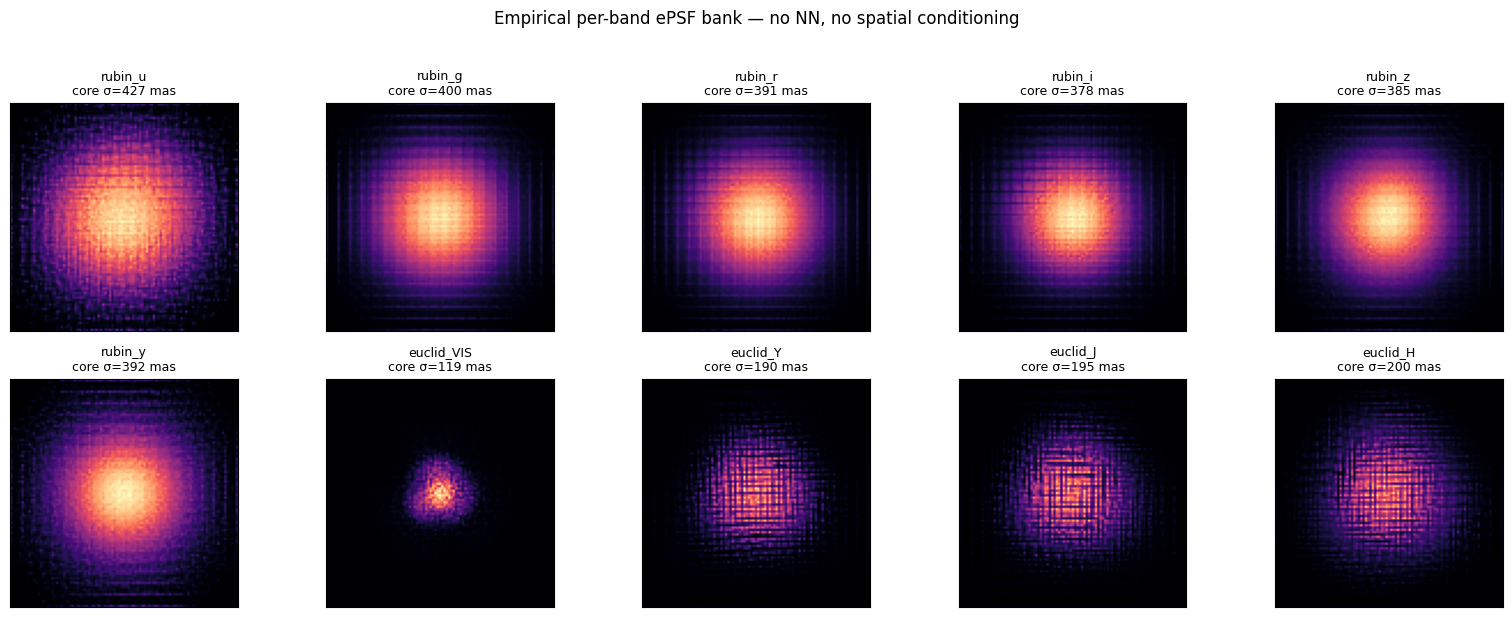

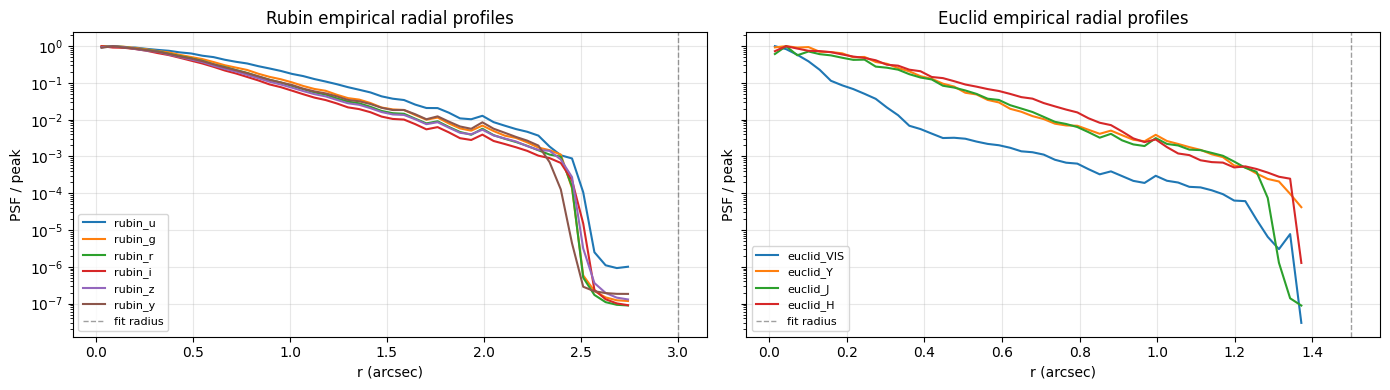

In [16]:
def emp_core_sigma_mas(psf_oversampled, oversampling, band, r_native=5.0):
    p = np.asarray(psf_oversampled, dtype=np.float64)
    P = p.shape[0]
    c = (P - 1) / 2.0
    yy, xx = np.indices(p.shape, dtype=np.float64)
    r_ovs = np.hypot(xx - c, yy - c)
    mask = r_ovs <= r_native * oversampling
    w = np.clip(p, 0.0, None) * mask
    tot = w.sum()
    if tot <= 0:
        return float("nan")
    sig2 = float((w * (r_ovs ** 2)).sum() / tot) / 2.0
    return np.sqrt(max(sig2, 0.0)) * (BAND_PIXEL_SCALE_ARCSEC[band] / oversampling) * 1000.0


def emp_radial_profile(psf, oversampling, band, n_bins=48):
    p = np.asarray(psf, dtype=np.float64)
    P = p.shape[0]
    c = (P - 1) / 2.0
    yy, xx = np.indices(p.shape, dtype=np.float64)
    r_native = np.hypot(xx - c, yy - c) / float(oversampling)
    bins = np.linspace(0, r_native.max(), n_bins + 1)
    rr, prof = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (r_native >= lo) & (r_native < hi)
        if m.any():
            rr.append(0.5 * (lo + hi) * BAND_PIXEL_SCALE_ARCSEC[band])
            prof.append(float(np.mean(p[m])))
    rr = np.asarray(rr)
    prof = np.asarray(prof)
    if prof.size and np.nanmax(prof) > 0:
        prof = prof / np.nanmax(prof)
    return rr, prof

if not EMPIRICAL_AVAILABLE:
    print("Empirical ePSF bank is not available yet; run the build cell above first.")
else:
    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
    for ax, band, psf in zip(axes.ravel(), ALL_BANDS, EMPIRICAL_BASE_BANK):
        peak = float(np.nanmax(psf))
        img = np.arcsinh(psf / max(peak * 0.03, 1e-12))
        pix_scale = BAND_PIXEL_SCALE_ARCSEC[band] / EMPIRICAL_OVERSAMPLING
        extent = np.array([-0.5, 0.5, -0.5, 0.5]) * psf.shape[0] * pix_scale
        ax.imshow(img, origin="lower", cmap="magma", extent=extent)
        ax.set_title(f"{band}\ncore σ={emp_core_sigma_mas(psf, EMPIRICAL_OVERSAMPLING, band):.0f} mas", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle("Empirical per-band ePSF bank — no NN, no spatial conditioning", y=1.02)
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    for band, psf in zip(ALL_BANDS, EMPIRICAL_BASE_BANK):
        r, prof = emp_radial_profile(psf, EMPIRICAL_OVERSAMPLING, band)
        axes[0 if band.startswith("rubin") else 1].plot(r, prof, label=band)
    axes[0].axvline(EMPIRICAL_LOSS_RADIUS_PX * 0.2, color="0.25", ls="--", lw=1.0, alpha=0.5, label="fit radius")
    axes[1].axvline(EMPIRICAL_LOSS_RADIUS_PX * 0.1, color="0.25", ls="--", lw=1.0, alpha=0.5, label="fit radius")
    axes[0].set_title("Rubin empirical radial profiles")
    axes[1].set_title("Euclid empirical radial profiles")
    for ax in axes:
        ax.set_yscale("log")
        ax.set_xlabel("r (arcsec)")
        ax.set_ylabel("PSF / peak")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


Empirical-base held-out sample: up to 100/band, 50 <= SNR <= 1000
held-out tiles: 79 / 790  (seed=0, val_frac=0.10)


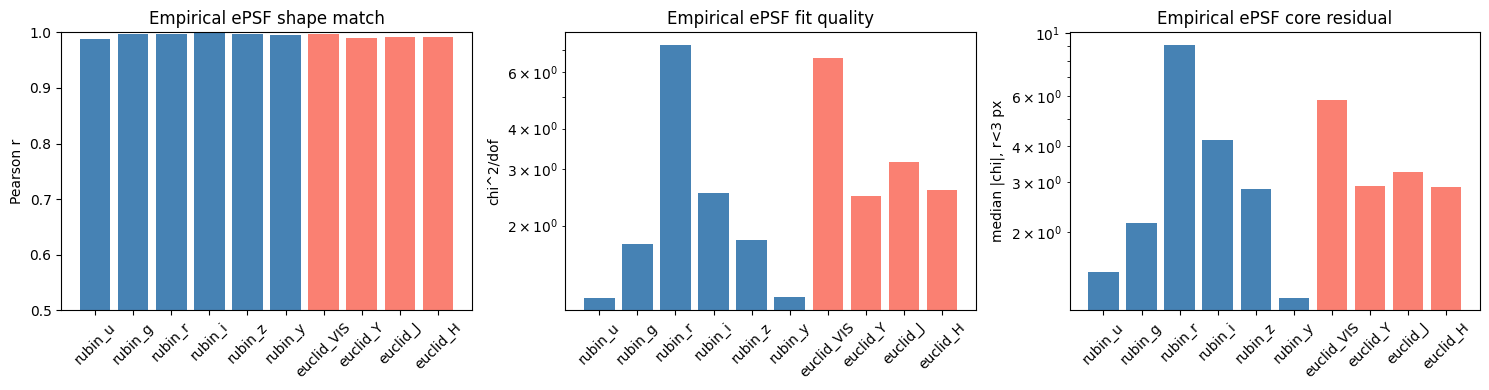


band                N       r   chi2/dof  med |chi|      core      wing
rubin_u            56   0.989       1.20      0.722     1.449     0.737
rubin_g            33   0.997       1.76      0.787     2.160     0.740
rubin_r            10   0.997       7.27      0.847     9.073     0.883
rubin_i             7   0.998       2.51      0.762     4.212     0.749
rubin_z            20   0.998       1.81      0.747     2.829     0.741
rubin_y            71   0.994       1.20      0.721     1.180     0.731
euclid_VIS        100   0.997       6.64      0.808     5.823     0.888
euclid_Y          100   0.990       2.47      0.511     2.899     0.641
euclid_J          100   0.991       3.14      0.744     3.252     0.768
euclid_H          100   0.991       2.58      0.684     2.893     0.771


In [17]:
def _emp_chi2(pred, obs, rms):
    pred = np.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0)
    obs = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)
    rms_fill = float(np.nanmedian(rms[np.isfinite(rms)])) if np.isfinite(rms).any() else 1.0
    rms = np.nan_to_num(rms, nan=rms_fill, posinf=rms_fill, neginf=rms_fill)
    inv_var = 1.0 / np.maximum(rms, 1e-6) ** 2
    return float(((pred - obs) ** 2 * inv_var).sum()) / max(int(obs.size - 1), 1)


def _emp_pearson(a, b):
    a = np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0).ravel().astype(np.float64)
    b = np.nan_to_num(b, nan=0.0, posinf=0.0, neginf=0.0).ravel().astype(np.float64)
    a = a - a.mean(); b = b - b.mean()
    den = np.sqrt((a*a).sum()) * np.sqrt((b*b).sum())
    return float((a*b).sum() / max(den, 1e-12))


def _emp_fit_flux_bg(pred, obs, rms):
    pred = np.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0)
    obs = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)
    rms_fill = float(np.nanmedian(rms[np.isfinite(rms)])) if np.isfinite(rms).any() else 1.0
    rms = np.nan_to_num(rms, nan=rms_fill, posinf=rms_fill, neginf=rms_fill)
    weight = 1.0 / np.maximum(rms, 1e-6) ** 2
    a = float((weight * pred * pred).sum())
    b = float((weight * pred).sum())
    c = float(weight.sum())
    d = float((weight * pred * obs).sum())
    e = float((weight * obs).sum())
    det = max(a * c - b * b, 1e-12)
    flux = max((d * c - b * e) / det, 0.0)
    bg = (a * e - b * d) / det
    return flux * pred + bg


def _emp_chi_regions(model, obs, rms, frac_xy):
    rms_fill = float(np.nanmedian(rms[np.isfinite(rms)])) if np.isfinite(rms).any() else 1.0
    rms = np.nan_to_num(rms, nan=rms_fill, posinf=rms_fill, neginf=rms_fill)
    chi = (model - obs) / np.maximum(rms, 1e-6)
    H, W = obs.shape
    yy, xx = np.indices(obs.shape, dtype=np.float32)
    rr = np.hypot(xx - (W // 2 + frac_xy[0]), yy - (H // 2 + frac_xy[1]))
    out = {"all": float(np.nanmedian(np.abs(chi)))}
    core = rr < 3.0
    wing = (rr >= 5.0) & (rr < 10.0)
    out["core"] = float(np.nanmedian(np.abs(chi[core]))) if core.any() else float("nan")
    out["wing"] = float(np.nanmedian(np.abs(chi[wing]))) if wing.any() else float("nan")
    return out

if not EMPIRICAL_AVAILABLE:
    print("Empirical ePSF bank is not available yet; run the build cell above first.")
else:
    EMP_TOP_K = 100
    EMP_SNR_MIN = 50.0
    EMP_SNR_MAX = 1000.0
    EMP_BATCH = 128
    rng = np.random.default_rng(7)

    pairs_emp = discover_tile_pairs(str(RUBIN_DIR), str(EUCLID_DIR))
    try:
        _head_meta_for_split = torch.load(str(HEAD_CKPT), map_location="cpu", weights_only=False)
        emp_val_frac = float(_head_meta_for_split.get("config", {}).get("val_frac", 0.10))
        emp_seed = int(_head_meta_for_split.get("config", {}).get("seed", 0))
    except Exception:
        emp_val_frac, emp_seed = 0.10, 0
    _train_emp, val_emp = split_tile_pairs(pairs_emp, val_frac=emp_val_frac, seed=emp_seed)
    emp_heldout_tiles = {tid for tid, _rp, _ep in val_emp}
    print(f"Empirical-base held-out sample: up to {EMP_TOP_K}/band, {EMP_SNR_MIN:g} <= SNR <= {EMP_SNR_MAX:g}")
    print(f"held-out tiles: {len(emp_heldout_tiles)} / {len(pairs_emp)}  (seed={emp_seed}, val_frac={emp_val_frac:.2f})")

    records_by_band = {b: [] for b in ALL_BANDS}
    for bi, band in enumerate(ALL_BANDS):
        p = TRAIN_DIR / f"{band}.npz"
        if not p.exists():
            continue
        d = np.load(p, allow_pickle=False)
        finite_stamp = np.isfinite(d["stamps"]).mean(axis=(1, 2)) > 0.95
        finite_rms = np.isfinite(d["rms"]).mean(axis=(1, 2)) > 0.95
        snr_ok = (d["snr"] >= EMP_SNR_MIN) & (d["snr"] <= EMP_SNR_MAX)
        tile_ok = np.array([str(t) in emp_heldout_tiles for t in d["tile_id"]], dtype=bool)
        valid = np.isfinite(d["snr"]) & finite_stamp & finite_rms & snr_ok & tile_ok
        valid_idx = np.where(valid)[0]
        if valid_idx.size == 0:
            continue
        pick = rng.choice(valid_idx, size=min(EMP_TOP_K, valid_idx.size), replace=False)
        for k in pick:
            records_by_band[band].append({
                "stamp": d["stamps"][k].astype(np.float32),
                "rms": np.maximum(d["rms"][k].astype(np.float32), 1e-6),
                "frac_xy": d["frac_xy"][k].astype(np.float32),
                "snr": float(d["snr"][k]),
            })

    emp_results = {}
    for bi, band in enumerate(ALL_BANDS):
        recs = records_by_band[band]
        if not recs:
            continue
        band_rows = []
        epsf_one = torch.from_numpy(EMPIRICAL_BASE_BANK[bi]).to(EMP_DEVICE).view(1, 1, EMPIRICAL_PSF_SIZE, EMPIRICAL_PSF_SIZE)
        for start in range(0, len(recs), EMP_BATCH):
            chunk = recs[start:start + EMP_BATCH]
            frac_t = torch.tensor(np.stack([r["frac_xy"] for r in chunk]), device=EMP_DEVICE)
            epsf_t = epsf_one.expand(len(chunk), -1, -1, -1)
            with torch.no_grad():
                native = EMP_RENDER_HEAD.render_at_native(epsf_t, frac_t, stamp_size=chunk[0]["stamp"].shape[-1])
            preds = native.squeeze(1).detach().cpu().numpy()
            for r, pred in zip(chunk, preds):
                model = _emp_fit_flux_bg(pred, r["stamp"], r["rms"])
                regions = _emp_chi_regions(model, r["stamp"], r["rms"], r["frac_xy"])
                band_rows.append({
                    "r": _emp_pearson(model, r["stamp"]),
                    "chi2": _emp_chi2(model, r["stamp"], r["rms"]),
                    **regions,
                })
        emp_results[band] = {
            "n": len(band_rows),
            "r": float(np.median([x["r"] for x in band_rows])),
            "chi2": float(np.median([x["chi2"] for x in band_rows])),
            "chi_all": float(np.median([x["all"] for x in band_rows])),
            "chi_core": float(np.median([x["core"] for x in band_rows])),
            "chi_wing": float(np.median([x["wing"] for x in band_rows])),
        }

    bands_ok = list(emp_results)
    colors = ["steelblue" if b.startswith("rubin") else "salmon" for b in bands_ok]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].bar(bands_ok, [emp_results[b]["r"] for b in bands_ok], color=colors)
    axes[0].set_ylim(0.5, 1.0); axes[0].set_ylabel("Pearson r"); axes[0].set_title("Empirical ePSF shape match")
    axes[1].bar(bands_ok, [emp_results[b]["chi2"] for b in bands_ok], color=colors)
    axes[1].set_yscale("log"); axes[1].set_ylabel("chi^2/dof"); axes[1].set_title("Empirical ePSF fit quality")
    axes[2].bar(bands_ok, [emp_results[b]["chi_core"] for b in bands_ok], color=colors)
    axes[2].set_yscale("log"); axes[2].set_ylabel("median |chi|, r<3 px"); axes[2].set_title("Empirical ePSF core residual")
    for ax in axes:
        ax.tick_params(axis="x", rotation=45)
    plt.tight_layout(); plt.show()

    print()
    print(f"{'band':14s} {'N':>6s} {'r':>7s} {'chi2/dof':>10s} {'med |chi|':>10s} {'core':>9s} {'wing':>9s}")
    for band in bands_ok:
        x = emp_results[band]
        print(f"{band:14s} {x['n']:6d} {x['r']:7.3f} {x['chi2']:10.2f} {x['chi_all']:10.3f} {x['chi_core']:9.3f} {x['chi_wing']:9.3f}")


## 4. Load FoundationEPSFHead

Loads the trained `FoundationEPSFHead` from the latest checkpoint, wraps the
foundation encoder (path read from the head checkpoint's saved config), and
encodes one tile so subsequent cells can query the head without re-encoding.

The head predicts `ePSF = per-band base ePSF + low-rank residual`, where the
residual coefficients are conditioned on frozen JAISP foundation features at
the source's VIS-frame position, the normalised tile position, and the band
id. Output is positive and unit-flux at every query point.

In [7]:
from matplotlib.colors import LogNorm

from load_foundation import load_foundation
from foundation_utils import FrozenEncoder, discover_tile_pairs, load_tile_data
from astrometry2.dataset import split_tile_pairs
from psf.foundation_epsf_head import (
    ALL_BANDS as HEAD_BANDS,
    RUBIN_BANDS as HEAD_RUBIN_BANDS,
    BAND_PIXEL_SCALE_ARCSEC,
    load_foundation_epsf_head,
)
RUBIN_DIR = ROOT / "data/rubin_tiles_all"
EUCLID_DIR = ROOT / "data/euclid_tiles_all"

def core_sigma_mas(psf_oversampled, oversampling, band, r_native=5.0):
    """Intensity-weighted core sigma (mas) inside r_native native pixels."""
    p = np.asarray(psf_oversampled, dtype=np.float64)
    P = p.shape[0]
    c = (P - 1) / 2.0
    yy, xx = np.indices(p.shape, dtype=np.float64)
    r_ovs = np.hypot(xx - c, yy - c)
    mask = r_ovs <= r_native * oversampling
    w = np.clip(p, 0.0, None) * mask
    tot = w.sum()
    if tot <= 0:
        return float("nan")
    sig2 = float((w * (r_ovs ** 2)).sum() / tot) / 2.0
    sigma_ovs = float(np.sqrt(max(sig2, 0.0)))
    return sigma_ovs * (BAND_PIXEL_SCALE_ARCSEC[band] / oversampling) * 1000.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_meta = torch.load(str(HEAD_CKPT), map_location="cpu", weights_only=False)
head = load_foundation_epsf_head(HEAD_CKPT, device=device)
head.eval()
foundation_ckpt = ROOT / ckpt_meta["config"]["foundation_checkpoint"]
foundation = load_foundation(str(foundation_ckpt), device=torch.device("cpu"), freeze=True)
frozen = FrozenEncoder(foundation).to(device).eval()
val_loss = ckpt_meta.get("val_metrics", {}).get("loss", float("nan"))
print(f"head: epoch={ckpt_meta.get('epoch')}  val_loss={val_loss:.4f}")
print(f"foundation: {foundation_ckpt.name}")
print(f"psf_size={head.psf_size}  oversampling={head.oversampling}")

PAIRS = discover_tile_pairs(str(RUBIN_DIR), str(EUCLID_DIR))
TILE_PATH = {tid: (rp, ep) for tid, rp, ep in PAIRS}
VAL_FRAC = float(ckpt_meta.get("config", {}).get("val_frac", 0.10))
SPLIT_SEED = int(ckpt_meta.get("config", {}).get("seed", 0))
TRAIN_PAIRS, VAL_PAIRS = split_tile_pairs(PAIRS, val_frac=VAL_FRAC, seed=SPLIT_SEED)
HELDOUT_TILE_IDS = {tid for tid, _rp, _ep in VAL_PAIRS}
print(f"held-out tiles: {len(HELDOUT_TILE_IDS)} / {len(PAIRS)}  (seed={SPLIT_SEED}, val_frac={VAL_FRAC:.2f})")

def _pos_vis_from_npz(d, k, band_idx):
    """Return true VIS-frame source position if present; fallback to old Rubin*2 convention."""
    if "pos_vis_pix" in d.files:
        return d["pos_vis_pix"][k].astype(np.float32)
    pos = d["pos_pix"][k].astype(np.float32).copy()
    if int(band_idx) < len(HEAD_RUBIN_BANDS):
        pos *= 2.0
    return pos

def _source_positions_vis_from_records(recs):
    return np.stack([r["pos_vis_pix"] for r in recs]).astype(np.float32)

def _heldout_tile_mask(d):
    return np.array([str(t) in HELDOUT_TILE_IDS and str(t) in TILE_PATH for t in d["tile_id"]], dtype=bool)

# Pre-encode one tile and store field-centre ePSFs for sections 4 and 5.
DEMO_TILE_ID, demo_rubin, demo_euclid = PAIRS[0]
print(f"demo tile: {DEMO_TILE_ID}")

with torch.no_grad():
    ctx_imgs, ctx_rms, _vis_hw, _wcs = load_tile_data(demo_rubin, demo_euclid, device)
    vis_img = ctx_imgs["euclid_VIS"]
    vis_rms = ctx_rms["euclid_VIS"]
    DEMO_BOTTLENECK = frozen.encoder(ctx_imgs, ctx_rms)["bottleneck"]
    DEMO_VIS_STEM = frozen.vis_stem(vis_img, vis_rms)
    DEMO_VIS_HW = (vis_img.shape[-2], vis_img.shape[-1])

    n_bands = len(HEAD_BANDS)
    pos_norm = torch.zeros(n_bands, 2, device=device)
    band_idx = torch.arange(n_bands, device=device)
    src_pos_vis = torch.tensor(
        [[DEMO_VIS_HW[1] * 0.5, DEMO_VIS_HW[0] * 0.5]] * n_bands,
        device=device, dtype=torch.float32,
    )
    out = head(
        pos_norm,
        band_idx,
        bottleneck=DEMO_BOTTLENECK,
        vis_stem_features=DEMO_VIS_STEM,
        source_positions_vis=src_pos_vis,
        fused_hw=(DEMO_BOTTLENECK.shape[-2], DEMO_BOTTLENECK.shape[-1]),
        vis_hw=DEMO_VIS_HW,
        return_dict=True,
    )
    EPSF_FIELD_CENTRE = out["epsf"][:, 0].detach().cpu().numpy()  # [B, P, P]
    EPSF_BASE_FIELD_CENTRE = head.base_epsf().detach().cpu().numpy()
    EPSF_DELTA_FIELD_CENTRE = EPSF_FIELD_CENTRE - EPSF_BASE_FIELD_CENTRE
    COEFF_FIELD_CENTRE = out["coeff"].detach().cpu().numpy()
    RESIDUAL_LOGITS_FIELD_CENTRE = out["residual_logits"].detach().cpu().numpy()

print()
print(f"{'band':12s} {'core σ (mas)':>14s}")
for band, p in zip(HEAD_BANDS, EPSF_FIELD_CENTRE):
    print(f"{band:12s} {core_sigma_mas(p, head.oversampling, band):>14.0f}")

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt
head: epoch=30  val_loss=2.1764
foundation: checkpoint_best.pt
psf_size=99  oversampling=5
held-out tiles: 79 / 790  (seed=0, val_frac=0.10)
demo tile: tile_x00000_y00000_tract5063_patch_14

band           core σ (mas)
rubin_u                 427
rubin_g                 400
rubin_r                 391
rubin_i                 378
rubin_z                 385
rubin_y                 392
euclid_VIS              119
euclid_Y                190
euclid_J                195


## 5. Per-band predicted ePSF at field centre (log scale, core σ in title)

Predicted PSF per band at the demo tile's field centre. Log colormap (3
decades from peak) with the noise floor clipped. Title reports the
intensity-weighted core σ inside 5 native pixels.

Expected band σ (FWHM/2.35): Rubin ~300-400 mas, Euclid VIS ~70-150 mas,
Euclid Y/J/H ~170-200 mas.

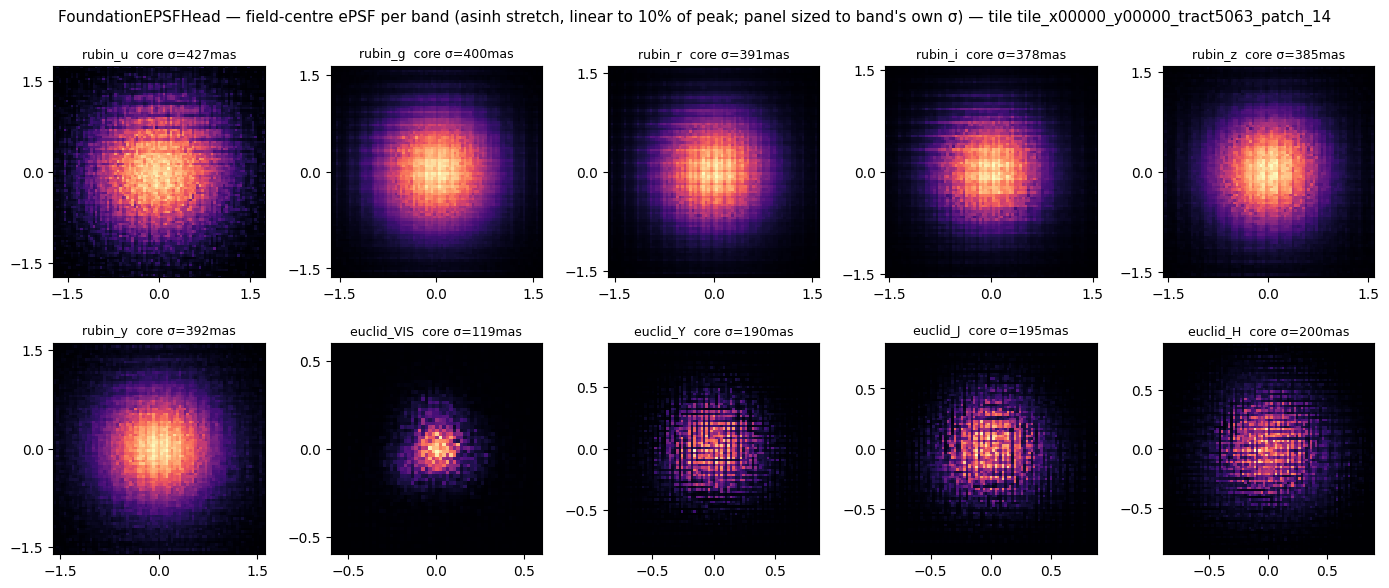

In [8]:
# Asinh stretch (Lupton): linear near the peak, log-like in the wings,
# no noise-floor cliff. Visible bright disc sits at ~1-2 sigma rather than
# the 3.7 sigma cliff that LogNorm with a 1e-3 clip produces.
#
# Per-band display half-extent: still sized to each PSF's own ~3.7 sigma so
# all panels reveal a comparable amount of wing context.

NOISE_FLOOR_SIGMAS = 3.72
PANEL_MARGIN_ARCSEC = 0.15
MIN_DISPLAY_HALF = 0.6
ASINH_LINEAR_FRAC = 0.10  # asinh is linear down to this fraction of peak

from matplotlib.colors import AsinhNorm

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, band, p in zip(axes.flat, HEAD_BANDS, EPSF_FIELD_CENTRE):
    P = p.shape[0]
    px_over = BAND_PIXEL_SCALE_ARCSEC[band] / head.oversampling
    data_ext = (P - 1) / 2.0 * px_over
    pk = float(p.max())

    sig_mas = core_sigma_mas(p, head.oversampling, band)
    sigma_arcsec = sig_mas / 1000.0
    panel_half = NOISE_FLOOR_SIGMAS * sigma_arcsec + PANEL_MARGIN_ARCSEC
    panel_half = max(MIN_DISPLAY_HALF, min(panel_half, data_ext))

    ax.imshow(
        p,
        origin="lower",
        cmap="magma",
        extent=[-data_ext, data_ext, -data_ext, data_ext],
        norm=AsinhNorm(linear_width=pk * ASINH_LINEAR_FRAC, vmin=0.0, vmax=pk),
        interpolation="nearest",
    )
    ax.set_title(f"{band}  core σ={sig_mas:.0f}mas", fontsize=9)
    ax.set_xlim(-panel_half, panel_half)
    ax.set_ylim(-panel_half, panel_half)
    if panel_half >= 1.5:
        ticks = [-1.5, 0, 1.5]
    elif panel_half >= 1.0:
        ticks = [-1, 0, 1]
    elif panel_half >= 0.6:
        ticks = [-0.5, 0, 0.5]
    else:
        ticks = [-0.3, 0, 0.3]
    ax.set_xticks(ticks); ax.set_yticks(ticks)
fig.suptitle(
    f"FoundationEPSFHead — field-centre ePSF per band "
    f"(asinh stretch, linear to {ASINH_LINEAR_FRAC:.0%} of peak; panel sized to band's own σ) "
    f"— tile {DEMO_TILE_ID}",
    fontsize=11,
)
plt.tight_layout(); plt.show()

## 6. Radial profile per band

Azimuthal-mean radial profile (log-y) of the field-centre ePSFs from
section 4. Real PSFs fall off rapidly to a noise floor; flat or rising tails
at large r mean residual contamination.

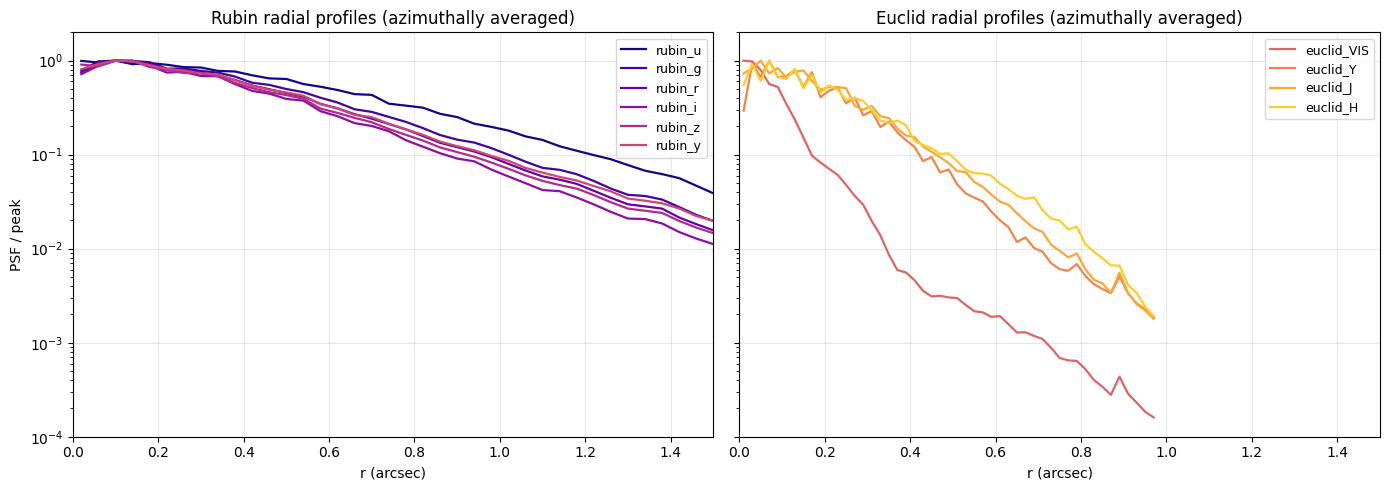

In [9]:
def radial_profile(psf, n_bins=None):
    P = psf.shape[0]
    half = (P - 1) / 2.0
    if n_bins is None:
        n_bins = max(8, int(half))
    yy, xx = np.indices(psf.shape, dtype=np.float32)
    r = np.sqrt((xx - half) ** 2 + (yy - half) ** 2)
    edges = np.linspace(0, half, n_bins + 1)
    centres, profile = [], []
    for k in range(n_bins):
        m = (r >= edges[k]) & (r < edges[k + 1])
        if m.any():
            centres.append(0.5 * (edges[k] + edges[k + 1]))
            profile.append(float(psf[m].mean()))
    return np.array(centres), np.array(profile)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = plt.cm.plasma(np.linspace(0, 0.9, len(HEAD_BANDS)))
for bi, (band, psf) in enumerate(zip(HEAD_BANDS, EPSF_FIELD_CENTRE)):
    r_ovs, prof = radial_profile(psf)
    px_arcsec = BAND_PIXEL_SCALE_ARCSEC[band] / head.oversampling
    r_arcsec = r_ovs * px_arcsec
    prof_norm = prof / max(prof.max(), 1e-12)
    ax = axes[0 if band.startswith("rubin") else 1]
    ax.plot(r_arcsec, prof_norm, color=colors[bi], lw=1.6, label=band)
for ax, title in zip(axes, ["Rubin", "Euclid"]):
    ax.set_yscale("log")
    ax.set_xlim(0, 1.5)
    ax.set_ylim(1e-4, 2)
    ax.set_xlabel("r (arcsec)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_title(f"{title} radial profiles (azimuthally averaged)")
axes[0].set_ylabel("PSF / peak")
plt.tight_layout(); plt.show()

## 7. Residual-head sanity check

Compare the smooth base ePSF to the full foundation-conditioned prediction at field centre. If the full profile develops non-monotonic radial bumps while the base is smooth, the learned residual head is creating structure rather than calibrating it. The coefficient table flags `tanh` saturation relative to the configured `head.coeff_scale`.

Coefficient saturation threshold: |c| > 0.294
band          base up  pred up pred max up %   mean |c|   p95 |c|  sat frac
rubin_u             2        2          4.46      0.300     0.300      1.00
rubin_g             4        4         19.96      0.300     0.300      1.00
rubin_r             3        3         20.04      0.300     0.300      1.00
rubin_i             4        4         16.41      0.300     0.300      1.00
rubin_z             2        2         13.01      0.300     0.300      1.00
rubin_y             3        3         10.69      0.300     0.300      1.00
euclid_VIS          0        0          0.02      0.300     0.300      1.00
euclid_Y           12       12         63.97      0.300     0.300      1.00
euclid_J            8        8         17.98      0.300     0.300      1.00
euclid_H            7        7         39.33      0.300     0.300      1.00


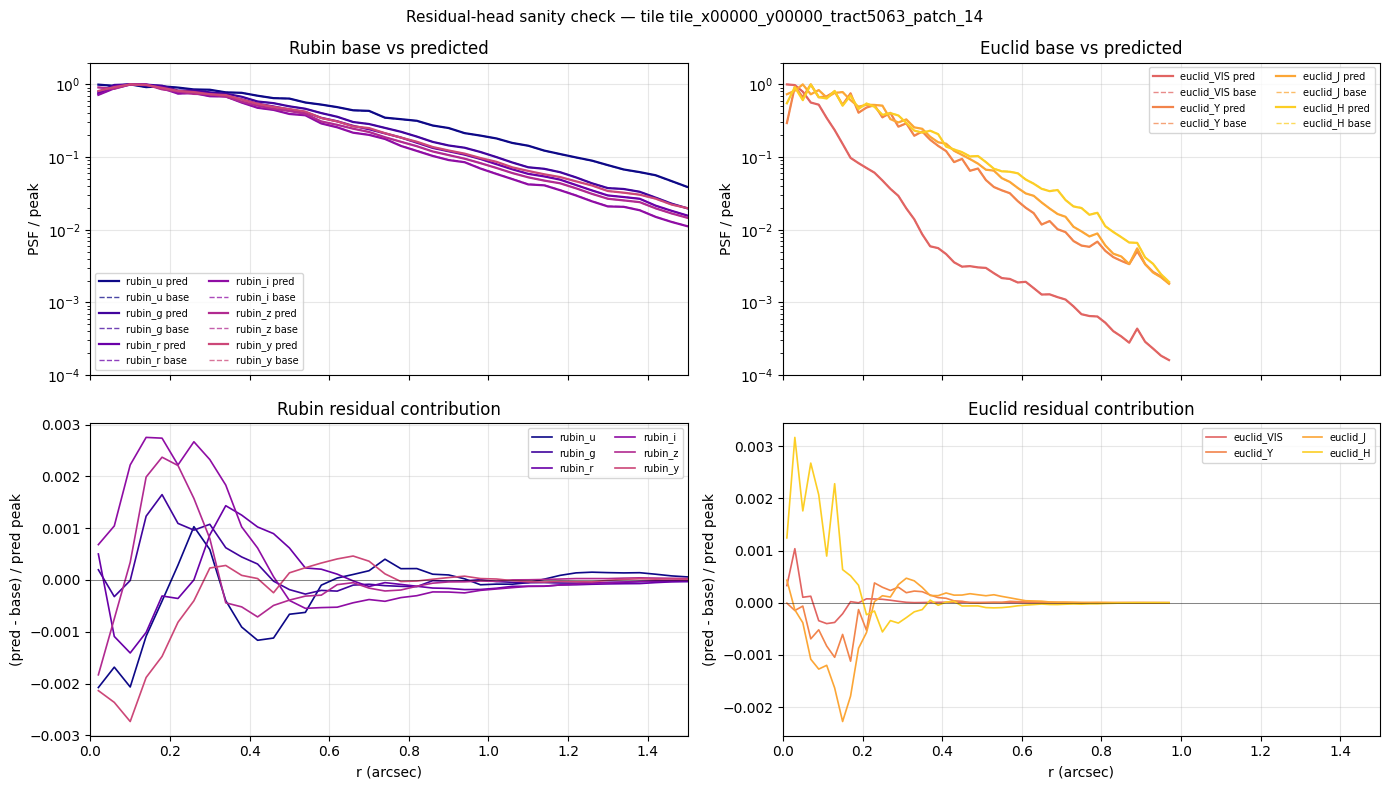

In [10]:
def _radial_monotonicity(psf):
    r, prof = radial_profile(psf)
    prof = prof / max(float(np.nanmax(prof)), 1e-12)
    diff = np.diff(prof)
    up = diff > max(1e-5, 0.002 * float(np.nanmax(prof)))
    max_up = float(np.nanmax(np.maximum(diff, 0.0))) if diff.size else 0.0
    return int(up.sum()), 100.0 * max_up

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex='col')
colors = plt.cm.plasma(np.linspace(0, 0.9, len(HEAD_BANDS)))
coeff_sat_threshold = 0.98 * float(getattr(head, 'coeff_scale', 1.0))
print(f"Coefficient saturation threshold: |c| > {coeff_sat_threshold:.3f}")
print(f"{'band':12s} {'base up':>8s} {'pred up':>8s} {'pred max up %':>13s} {'mean |c|':>10s} {'p95 |c|':>9s} {'sat frac':>9s}")
for bi, band in enumerate(HEAD_BANDS):
    px_arcsec = BAND_PIXEL_SCALE_ARCSEC[band] / head.oversampling
    r_base, prof_base = radial_profile(EPSF_BASE_FIELD_CENTRE[bi])
    r_pred, prof_pred = radial_profile(EPSF_FIELD_CENTRE[bi])
    r_delta, prof_delta = radial_profile(EPSF_DELTA_FIELD_CENTRE[bi])
    r_base *= px_arcsec; r_pred *= px_arcsec; r_delta *= px_arcsec
    prof_base_norm = prof_base / max(float(np.nanmax(prof_base)), 1e-12)
    prof_pred_norm = prof_pred / max(float(np.nanmax(prof_pred)), 1e-12)
    delta_norm = prof_delta / max(float(np.nanmax(EPSF_FIELD_CENTRE[bi])), 1e-12)
    col = colors[bi]
    ax = axes[0, 0 if band.startswith('rubin') else 1]
    ax.plot(r_pred, prof_pred_norm, color=col, lw=1.6, label=f'{band} pred')
    ax.plot(r_base, prof_base_norm, color=col, lw=1.0, ls='--', alpha=0.75, label=f'{band} base')
    ax = axes[1, 0 if band.startswith('rubin') else 1]
    ax.plot(r_delta, delta_norm, color=col, lw=1.2, label=band)
    base_up, _ = _radial_monotonicity(EPSF_BASE_FIELD_CENTRE[bi])
    pred_up, pred_max_up = _radial_monotonicity(EPSF_FIELD_CENTRE[bi])
    coeff_abs = np.abs(COEFF_FIELD_CENTRE[bi])
    print(f"{band:12s} {base_up:8d} {pred_up:8d} {pred_max_up:13.2f} {coeff_abs.mean():10.3f} {np.percentile(coeff_abs, 95):9.3f} {(coeff_abs > coeff_sat_threshold).mean():9.2f}")

for ax, title in zip(axes[0], ['Rubin base vs predicted', 'Euclid base vs predicted']):
    ax.set_yscale('log')
    ax.set_xlim(0, 1.5)
    ax.set_ylim(1e-4, 2)
    ax.grid(alpha=0.3)
    ax.set_title(title)
    ax.set_ylabel('PSF / peak')
for ax, title in zip(axes[1], ['Rubin residual contribution', 'Euclid residual contribution']):
    ax.axhline(0, color='k', lw=0.6, alpha=0.5)
    ax.set_xlim(0, 1.5)
    ax.grid(alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel('r (arcsec)')
    ax.set_ylabel('(pred - base) / pred peak')
for ax in axes.flat:
    ax.legend(fontsize=7, ncol=2)
fig.suptitle(f'Residual-head sanity check — tile {DEMO_TILE_ID}', fontsize=11)
plt.tight_layout(); plt.show()

## 8. Held-out validation — shape match per band

Pearson r and chi^2/dof for the head rendered at the top-5 SNR Gaia stars per
band. Per band we collect the highest-SNR stamps across the training set,
group by tile id, encode each unique tile once, then query the head with each
star's `pos_norm` and VIS-frame source position. Pearson r is the meaningful
cross-band number (normalised, shape-only); chi^2/dof grows with stamp
brightness — compare across bands rather than to 1.

Using random held-out sample: up to 100 per band, 50 <= SNR <= 1000


Encoding 56 unique tiles for held-out validation...


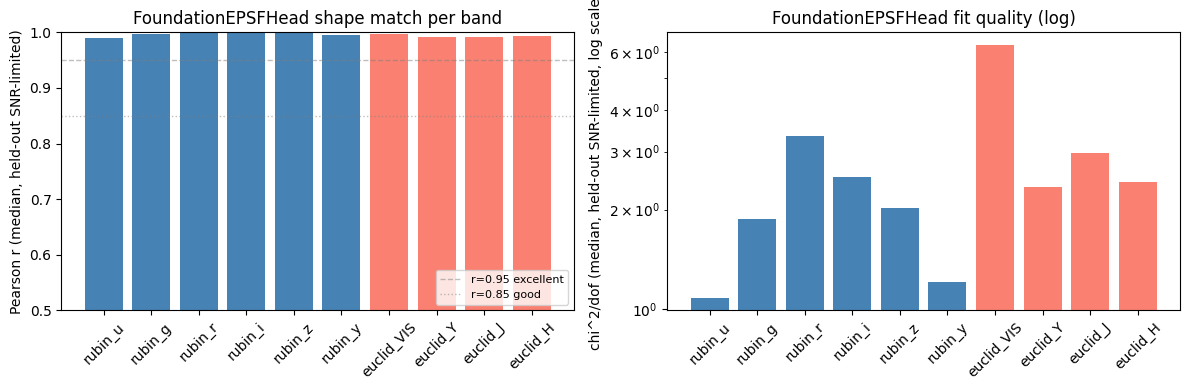


band            n_val        r     chi2/dof
rubin_u            56   0.990          1.1
rubin_g            33   0.997          1.9
rubin_r            10   0.998          3.4
rubin_i             7   0.999          2.5
rubin_z            20   0.998          2.0
rubin_y            71   0.994          1.2
euclid_VIS        100   0.997          6.3
euclid_Y          100   0.992          2.3
euclid_J          100   0.992          3.0
euclid_H          100   0.993          2.4


In [11]:
def _chi2(pred, obs, rms):
    pred = np.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0)
    obs = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)
    rms_fill = float(np.nanmedian(rms[np.isfinite(rms)])) if np.isfinite(rms).any() else 1.0
    rms = np.nan_to_num(rms, nan=rms_fill, posinf=rms_fill, neginf=rms_fill)
    inv_var = 1.0 / np.maximum(rms, 1e-6) ** 2
    return float(((pred - obs) ** 2 * inv_var).sum()) / max(int(obs.size - 1), 1)

def _pearson(a, b):
    a = np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0).ravel().astype(np.float64)
    b = np.nan_to_num(b, nan=0.0, posinf=0.0, neginf=0.0).ravel().astype(np.float64)
    a = a - a.mean(); b = b - b.mean()
    den = np.sqrt((a*a).sum()) * np.sqrt((b*b).sum())
    return float((a*b).sum() / max(den, 1e-12))

def _fit_flux_bg(pred, obs, rms):
    pred = np.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0)
    obs = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)
    rms_fill = float(np.nanmedian(rms[np.isfinite(rms)])) if np.isfinite(rms).any() else 1.0
    rms = np.nan_to_num(rms, nan=rms_fill, posinf=rms_fill, neginf=rms_fill)
    weight = 1.0 / np.maximum(rms, 1e-6) ** 2
    a = float((weight * pred * pred).sum())
    b = float((weight * pred).sum())
    c = float(weight.sum())
    d = float((weight * pred * obs).sum())
    e = float((weight * obs).sum())
    det = max(a * c - b * b, 1e-12)
    flux = max((d * c - b * e) / det, 0.0)
    bg = (a * e - b * d) / det
    return flux * pred + bg

VALIDATION_DIR = TRAIN_DIR
TOP_K = 100
SNR_MIN = 50.0
SNR_MAX = 1000.0
RNG = np.random.default_rng(7)
print(f"Using random held-out sample: up to {TOP_K} per band, {SNR_MIN:g} <= SNR <= {SNR_MAX:g}")


records_by_tile = {}
for bi, band in enumerate(HEAD_BANDS):
    p = VALIDATION_DIR / f"{band}.npz"
    if not p.exists():
        continue
    d = np.load(p, allow_pickle=False)
    finite_stamp = np.isfinite(d['stamps']).mean(axis=(1, 2)) > 0.95
    finite_rms = np.isfinite(d['rms']).mean(axis=(1, 2)) > 0.95
    snr_ok = (d['snr'] >= SNR_MIN) & (d['snr'] <= SNR_MAX)
    valid = np.isfinite(d['snr']) & finite_stamp & finite_rms & _heldout_tile_mask(d) & snr_ok
    valid_idx = np.where(valid)[0]
    if valid_idx.size == 0:
        continue
    n_pick = min(TOP_K, valid_idx.size)
    order = RNG.choice(valid_idx, size=n_pick, replace=False)
    for k in order:
        tile = str(d['tile_id'][k])
        if tile not in TILE_PATH:
            continue
        records_by_tile.setdefault(tile, []).append({
            'band': band, 'band_idx': bi,
            'stamp': d['stamps'][k].astype(np.float32),
            'rms': d['rms'][k].astype(np.float32),
            'frac_xy': d['frac_xy'][k].astype(np.float32),
            'pos_norm': d['pos_norm'][k].astype(np.float32),
            'pos_pix': d['pos_pix'][k].astype(np.float32),
            'pos_vis_pix': _pos_vis_from_npz(d, k, bi),
            'snr': float(d['snr'][k]),
        })

per_band = {b: [] for b in HEAD_BANDS}
n_rubin_bands = len(HEAD_RUBIN_BANDS)
print(f"Encoding {len(records_by_tile)} unique tiles for held-out validation...")
for tile_id, recs in records_by_tile.items():
    rubin_path, euclid_path = TILE_PATH[tile_id]
    with torch.no_grad():
        ctx_imgs, ctx_rms, _, _ = load_tile_data(rubin_path, euclid_path, device)
        vis_img = ctx_imgs['euclid_VIS']; vis_rms = ctx_rms['euclid_VIS']
        bn = frozen.encoder(ctx_imgs, ctx_rms)['bottleneck']
        stem = frozen.vis_stem(vis_img, vis_rms)
        H, W = vis_img.shape[-2:]
        pos_norm = torch.tensor(np.stack([r['pos_norm'] for r in recs]), device=device)
        band_idx = torch.tensor([r['band_idx'] for r in recs], device=device, dtype=torch.long)
        frac_xy = torch.tensor(np.stack([r['frac_xy'] for r in recs]), device=device)
        src_pos_vis_t = torch.tensor(_source_positions_vis_from_records(recs), device=device)
        out = head(
            pos_norm, band_idx,
            bottleneck=bn, vis_stem_features=stem,
            source_positions_vis=src_pos_vis_t,
            fused_hw=(bn.shape[-2], bn.shape[-1]), vis_hw=(H, W),
            return_dict=True,
        )
        stamp_size = recs[0]['stamp'].shape[-1]
        native = head.render_at_native(out['epsf'], frac_xy, stamp_size=stamp_size)
        pred = native.squeeze(1).cpu().numpy()

    for r, p_pred in zip(recs, pred):
        scaled = _fit_flux_bg(p_pred, r['stamp'], r['rms'])
        per_band[r['band']].append((_pearson(scaled, r['stamp']), _chi2(scaled, r['stamp'], r['rms'])))

results = {b: (float(np.median([x[1] for x in v])),
                float(np.median([x[0] for x in v])),
                len(v))
            for b, v in per_band.items() if v}
bands_ok  = list(results.keys())
chi2_vals = [results[b][0] for b in bands_ok]
r_vals    = [results[b][1] for b in bands_ok]
colors_   = ['steelblue' if b.startswith('rubin') else 'salmon' for b in bands_ok]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(bands_ok, r_vals, color=colors_)
axes[0].set_ylabel('Pearson r (median, held-out SNR-limited)')
axes[0].set_title('FoundationEPSFHead shape match per band')
axes[0].set_ylim(0.5, 1.0)
axes[0].axhline(0.95, color='gray', ls='--', lw=1, alpha=0.5, label='r=0.95 excellent')
axes[0].axhline(0.85, color='gray', ls=':',  lw=1, alpha=0.5, label='r=0.85 good')
axes[0].legend(fontsize=8, loc='lower right')
axes[1].bar(bands_ok, chi2_vals, color=colors_)
axes[1].set_yscale('log')
axes[1].set_ylabel('chi^2/dof (median, held-out SNR-limited, log scale)')
axes[1].set_title('FoundationEPSFHead fit quality (log)')
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print()
print(f"{'band':14s} {'n_val':>6s}   {'r':>6s}   {'chi2/dof':>10s}")
for band in bands_ok:
    chi2_v, r_v, n_pick = results[band]
    print(f'{band:14s} {n_pick:6d}   {r_v:.3f}   {chi2_v:>10.1f}')

## 9. Empirical base vs NN residual head

This compares the no-NN empirical ePSF bank from Section 3 against the loaded `FoundationEPSFHead` on the held-out validation summary from Section 8. The samples are drawn with the same split and SNR limits, so this is the quick decision cell: the residual head should only survive if it improves the empirical base by enough to justify the extra moving parts.


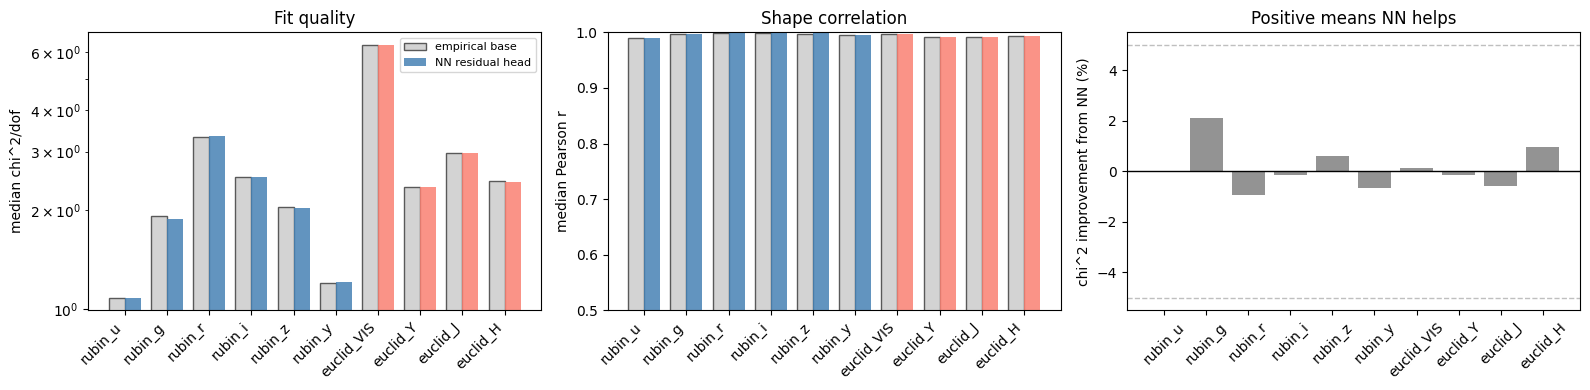


band               N emp/NN   chi2 emp    chi2 NN   gain %    r emp     r NN       Δr   emp core  emp |chi|
rubin_u           56/56          1.08       1.08      0.0    0.990    0.990    0.000      0.985      0.716
rubin_g           33/33          1.91       1.87      2.1    0.997    0.997    0.000      2.879      0.789
rubin_r           10/10          3.32       3.35     -1.0    0.998    0.998    0.000      5.551      0.813
rubin_i            7/7           2.51       2.52     -0.1    0.999    0.999   -0.000      3.825      0.770
rubin_z           20/20          2.03       2.02      0.6    0.998    0.998    0.000      2.801      0.746
rubin_y           71/71          1.20       1.21     -0.7    0.994    0.994    0.000      1.122      0.721
euclid_VIS       100/100         6.32       6.31      0.1    0.997    0.997   -0.000      5.198      0.809
euclid_Y         100/100         2.34       2.34     -0.1    0.992    0.992   -0.000      2.605      0.498
euclid_J         100/100         2.

In [12]:
def _nn_result_tuple(value):
    """Existing Section 8 stores results[band] = (chi2, r, n)."""
    if isinstance(value, dict):
        return float(value["chi2"]), float(value["r"]), int(value.get("n", value.get("n_val", 0)))
    chi2_v, r_v, n_v = value
    return float(chi2_v), float(r_v), int(n_v)

if "emp_results" not in globals() or not emp_results:
    print("Run Section 3 empirical held-out evaluation first; it defines emp_results.")
elif "results" not in globals() or not results:
    print("Run Section 8 FoundationEPSFHead held-out validation first; it defines results.")
else:
    common = [b for b in ALL_BANDS if b in emp_results and b in results]
    if not common:
        print("No overlapping bands between emp_results and results.")
    else:
        emp_chi2 = np.array([float(emp_results[b]["chi2"]) for b in common])
        emp_r = np.array([float(emp_results[b]["r"]) for b in common])
        emp_core = np.array([float(emp_results[b].get("chi_core", np.nan)) for b in common])
        emp_all = np.array([float(emp_results[b].get("chi_all", np.nan)) for b in common])
        nn_rows = [_nn_result_tuple(results[b]) for b in common]
        nn_chi2 = np.array([x[0] for x in nn_rows])
        nn_r = np.array([x[1] for x in nn_rows])
        nn_n = np.array([x[2] for x in nn_rows])
        emp_n = np.array([int(emp_results[b].get("n", 0)) for b in common])
        chi2_gain = 100.0 * (emp_chi2 - nn_chi2) / np.maximum(emp_chi2, 1e-12)
        r_delta = nn_r - emp_r
        colors = ["steelblue" if b.startswith("rubin") else "salmon" for b in common]
        x = np.arange(len(common))
        width = 0.38

        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        axes[0].bar(x - width/2, emp_chi2, width, label="empirical base", color="lightgray", edgecolor="0.35")
        axes[0].bar(x + width/2, nn_chi2, width, label="NN residual head", color=colors, alpha=0.85)
        axes[0].set_yscale("log")
        axes[0].set_ylabel("median chi^2/dof")
        axes[0].set_title("Fit quality")
        axes[0].legend(fontsize=8)

        axes[1].bar(x - width/2, emp_r, width, label="empirical base", color="lightgray", edgecolor="0.35")
        axes[1].bar(x + width/2, nn_r, width, label="NN residual head", color=colors, alpha=0.85)
        axes[1].set_ylim(0.5, 1.0)
        axes[1].set_ylabel("median Pearson r")
        axes[1].set_title("Shape correlation")

        gain_colors = ["seagreen" if g > 5 else "firebrick" if g < -5 else "gray" for g in chi2_gain]
        axes[2].bar(common, chi2_gain, color=gain_colors, alpha=0.85)
        axes[2].axhline(0, color="black", lw=1)
        axes[2].axhline(5, color="gray", lw=1, ls="--", alpha=0.5)
        axes[2].axhline(-5, color="gray", lw=1, ls="--", alpha=0.5)
        axes[2].set_ylabel("chi^2 improvement from NN (%)")
        axes[2].set_title("Positive means NN helps")

        for ax in axes[:2]:
            ax.set_xticks(x)
            ax.set_xticklabels(common, rotation=45, ha="right")
        axes[2].tick_params(axis="x", rotation=45)
        plt.tight_layout(); plt.show()

        print()
        print(f"{'band':14s} {'N emp/NN':>12s} {'chi2 emp':>10s} {'chi2 NN':>10s} {'gain %':>8s} {'r emp':>8s} {'r NN':>8s} {'Δr':>8s} {'emp core':>10s} {'emp |chi|':>10s}")
        for i, band in enumerate(common):
            print(
                f"{band:14s} {emp_n[i]:5d}/{nn_n[i]:<5d} "
                f"{emp_chi2[i]:10.2f} {nn_chi2[i]:10.2f} {chi2_gain[i]:8.1f} "
                f"{emp_r[i]:8.3f} {nn_r[i]:8.3f} {r_delta[i]:8.3f} "
                f"{emp_core[i]:10.3f} {emp_all[i]:10.3f}"
            )

        helped = [b for b, g in zip(common, chi2_gain) if g > 5]
        hurt = [b for b, g in zip(common, chi2_gain) if g < -5]
        flat = [b for b, g in zip(common, chi2_gain) if -5 <= g <= 5]
        print()
        print("NN helps (>5% chi2 gain):", helped if helped else "none")
        print("NN neutral (±5%):", flat if flat else "none")
        print("NN hurts (>5% worse):", hurt if hurt else "none")


## 10. Centroid-nuisance check

Dipole residuals usually mean the source centre is wrong at the few-hundredths to few-tenths pixel level. This cell keeps the predicted ePSF shape fixed, rerenders it over a small grid of extra `(dx, dy)` centroid offsets, refits flux/background, and reports how much median `|chi|` improves. Large improvement means the PSF model is being blamed for a centering/measurement error.

Testing centroid grid: 13x13, max shift=0.30 native px



band            N  |chi| before  |chi| after  improve %  med |dxy|  p90 |dxy|
rubin_u        56         0.715        0.696        2.8      0.180      0.293
rubin_g        33         0.784        0.731        6.8      0.112      0.176
rubin_r        10         0.809        0.742        8.2      0.127      0.180
rubin_i         7         0.761        0.747        1.9      0.071      0.150
rubin_z        20         0.743        0.718        3.4      0.071      0.141
rubin_y        71         0.721        0.702        2.7      0.112      0.158
euclid_VIS    100         0.810        0.786        2.9      0.100      0.207
euclid_Y      100         0.496        0.465        6.2      0.252      0.364
euclid_J      100         0.751        0.700        6.8      0.237      0.361
euclid_H      100         0.678        0.636        6.1      0.269      0.354


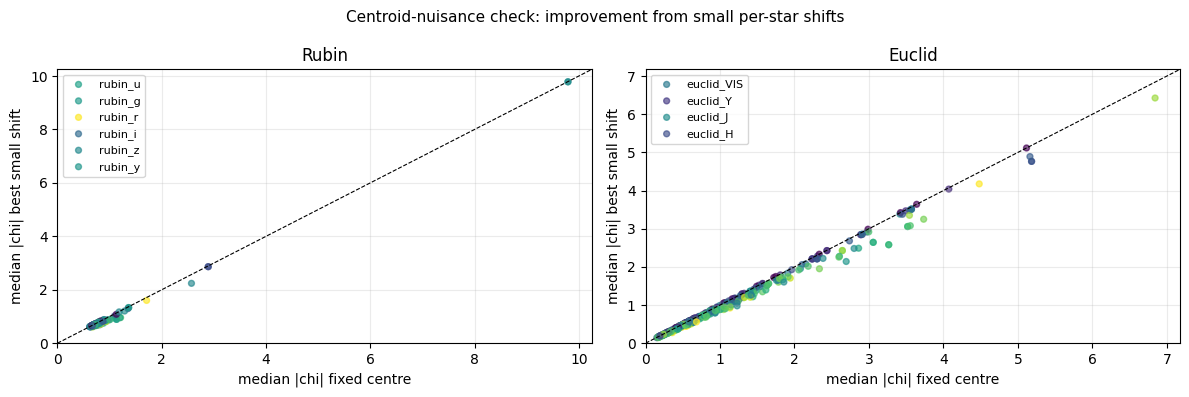

In [13]:
CENTROID_SHIFT_MAX = 0.30
CENTROID_SHIFT_N = 13
_shift_vals = np.linspace(-CENTROID_SHIFT_MAX, CENTROID_SHIFT_MAX, CENTROID_SHIFT_N).astype(np.float32)
SHIFT_GRID = np.array([[dx, dy] for dy in _shift_vals for dx in _shift_vals], dtype=np.float32)
ZERO_SHIFT_INDEX = int(np.argmin(np.sum(SHIFT_GRID ** 2, axis=1)))

def _fit_flux_bg_grid(native_grid, stamps_t, rms_t):
    # native_grid: [N, S, H, W], stamps_t/rms_t: [N, H, W]
    weight = 1.0 / rms_t[:, None].clamp(min=1e-6).pow(2)
    data = stamps_t[:, None]
    a = (weight * native_grid * native_grid).flatten(2).sum(dim=2)
    b = (weight * native_grid).flatten(2).sum(dim=2)
    c = weight.flatten(2).sum(dim=2)
    d_ = (weight * native_grid * data).flatten(2).sum(dim=2)
    e_ = (weight * data).flatten(2).sum(dim=2)
    det = (a * c - b * b).clamp_min(1e-12)
    flux = ((d_ * c - b * e_) / det).clamp_min(0.0)
    bg = (a * e_ - b * d_) / det
    model = flux[:, :, None, None] * native_grid + bg[:, :, None, None]
    chi = (data - model) / rms_t[:, None].clamp(min=1e-6)
    med_abs_chi = chi.abs().flatten(2).median(dim=2).values
    return model, med_abs_chi

per_band_centroid = {b: {'before': [], 'after': [], 'dx': [], 'dy': [], 'snr': []} for b in HEAD_BANDS}
print(f"Testing centroid grid: {CENTROID_SHIFT_N}x{CENTROID_SHIFT_N}, max shift={CENTROID_SHIFT_MAX:.2f} native px")
for tile_id, recs in records_by_tile.items():
    rubin_path, euclid_path = TILE_PATH[tile_id]
    with torch.no_grad():
        ctx_imgs, ctx_rms, _, _ = load_tile_data(rubin_path, euclid_path, device)
        vis_img = ctx_imgs['euclid_VIS']; vis_rms = ctx_rms['euclid_VIS']
        bn = frozen.encoder(ctx_imgs, ctx_rms)['bottleneck']
        stem = frozen.vis_stem(vis_img, vis_rms)
        H, W = vis_img.shape[-2:]
        pos_norm = torch.tensor(np.stack([r['pos_norm'] for r in recs]), device=device)
        band_idx = torch.tensor([r['band_idx'] for r in recs], device=device, dtype=torch.long)
        frac_xy = torch.tensor(np.stack([r['frac_xy'] for r in recs]), device=device)
        src_pos_vis_t = torch.tensor(_source_positions_vis_from_records(recs), device=device)
        out = head(
            pos_norm, band_idx,
            bottleneck=bn, vis_stem_features=stem,
            source_positions_vis=src_pos_vis_t,
            fused_hw=(bn.shape[-2], bn.shape[-1]), vis_hw=(H, W),
            return_dict=True,
        )
        N = len(recs)
        S = SHIFT_GRID.shape[0]
        shift_t = torch.tensor(SHIFT_GRID, device=device, dtype=frac_xy.dtype)
        frac_grid = (frac_xy[:, None, :] + shift_t[None, :, :]).reshape(N * S, 2)
        epsf_grid = out['epsf'][:, None].expand(N, S, 1, head.psf_size, head.psf_size).reshape(N * S, 1, head.psf_size, head.psf_size)
        stamp_size = recs[0]['stamp'].shape[-1]
        native_grid = head.render_at_native(epsf_grid, frac_grid, stamp_size=stamp_size).squeeze(1).reshape(N, S, stamp_size, stamp_size)
        stamps_t = torch.from_numpy(np.stack([r['stamp'] for r in recs])).to(device)
        rms_t = torch.from_numpy(np.stack([r['rms'] for r in recs])).to(device)
        _model_grid, med_abs_chi = _fit_flux_bg_grid(native_grid, stamps_t, rms_t)
        best = med_abs_chi.argmin(dim=1).detach().cpu().numpy()
        before = med_abs_chi[:, ZERO_SHIFT_INDEX].detach().cpu().numpy()
        after = med_abs_chi[torch.arange(N, device=device), torch.from_numpy(best).to(device)].detach().cpu().numpy()
    for k, r in enumerate(recs):
        b = r['band']
        dx, dy = SHIFT_GRID[int(best[k])]
        per_band_centroid[b]['before'].append(float(before[k]))
        per_band_centroid[b]['after'].append(float(after[k]))
        per_band_centroid[b]['dx'].append(float(dx))
        per_band_centroid[b]['dy'].append(float(dy))
        per_band_centroid[b]['snr'].append(float(r['snr']))

print()
print(f"{'band':12s} {'N':>4s} {'|chi| before':>13s} {'|chi| after':>12s} {'improve %':>10s} {'med |dxy|':>10s} {'p90 |dxy|':>10s}")
for band in HEAD_BANDS:
    vals = per_band_centroid[band]
    if not vals['before']:
        continue
    before = np.array(vals['before'])
    after = np.array(vals['after'])
    dx = np.array(vals['dx'])
    dy = np.array(vals['dy'])
    dr = np.hypot(dx, dy)
    improve = 100.0 * (1.0 - np.median(after) / max(np.median(before), 1e-12))
    print(f"{band:12s} {len(before):4d} {np.median(before):13.3f} {np.median(after):12.3f} {improve:10.1f} {np.median(dr):10.3f} {np.percentile(dr, 90):10.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for band in HEAD_BANDS:
    vals = per_band_centroid[band]
    if not vals['before']:
        continue
    before = np.array(vals['before'])
    after = np.array(vals['after'])
    dr = np.hypot(vals['dx'], vals['dy'])
    ax = axes[0 if band.startswith('rubin') else 1]
    ax.scatter(before, after, s=18, alpha=0.65, label=band, c=[dr], cmap='viridis')
for ax, title in zip(axes, ['Rubin', 'Euclid']):
    lim = ax.get_xlim()
    hi = max(lim[1], ax.get_ylim()[1])
    ax.plot([0, hi], [0, hi], color='k', lw=0.8, ls='--')
    ax.set_xlim(0, hi); ax.set_ylim(0, hi)
    ax.set_xlabel('median |chi| fixed centre')
    ax.set_ylabel('median |chi| best small shift')
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
fig.suptitle('Centroid-nuisance check: improvement from small per-star shifts', fontsize=11)
plt.tight_layout(); plt.show()

## 11. Spatial PSF map — T, e1, e2 across the tile FOV (WL diagnostic)

Predicts the ePSF on a grid of positions across the demo tile and computes
unweighted second moments (T = Q11+Q22, e1 = (Q11-Q22)/T, e2 = 2 Q12/T) for
each predicted PSF.

**What to look for:**
- **Smooth** spatial pattern (no salt-and-pepper, no chip-edge discontinuities).
- **Real position-dependent variation** captured (T should vary by a few %
  across FOV; e1/e2 by ~0.005-0.02 for typical surveys).
- **No catastrophic outlier patches** — the foundation-feature spatial
  conditioner should produce continuous predictions.

For weak-lensing precision the variation needs to track real per-star
measurements; the next step beyond this cell is to also bin held-out star
shapes spatially and compare to the model's prediction.

band         T mean (mas^2)   T std/mean %   |e1| max   |e2| max
rubin_u              757403          0.00%     0.0098     0.0264
rubin_g              614440          0.00%     0.0107     0.0038
rubin_r              573231          0.00%     0.0069     0.0033
rubin_i              513584          0.00%     0.0082     0.0152
rubin_z              565018          0.00%     0.0082     0.0094
rubin_y              627043          0.00%     0.0080     0.0051
euclid_VIS            49993          0.00%     0.0232     0.0292
euclid_Y             115860          0.00%     0.0028     0.0058
euclid_J             127889          0.00%     0.0173     0.0053
euclid_H             149513          0.00%     0.0024     0.0109


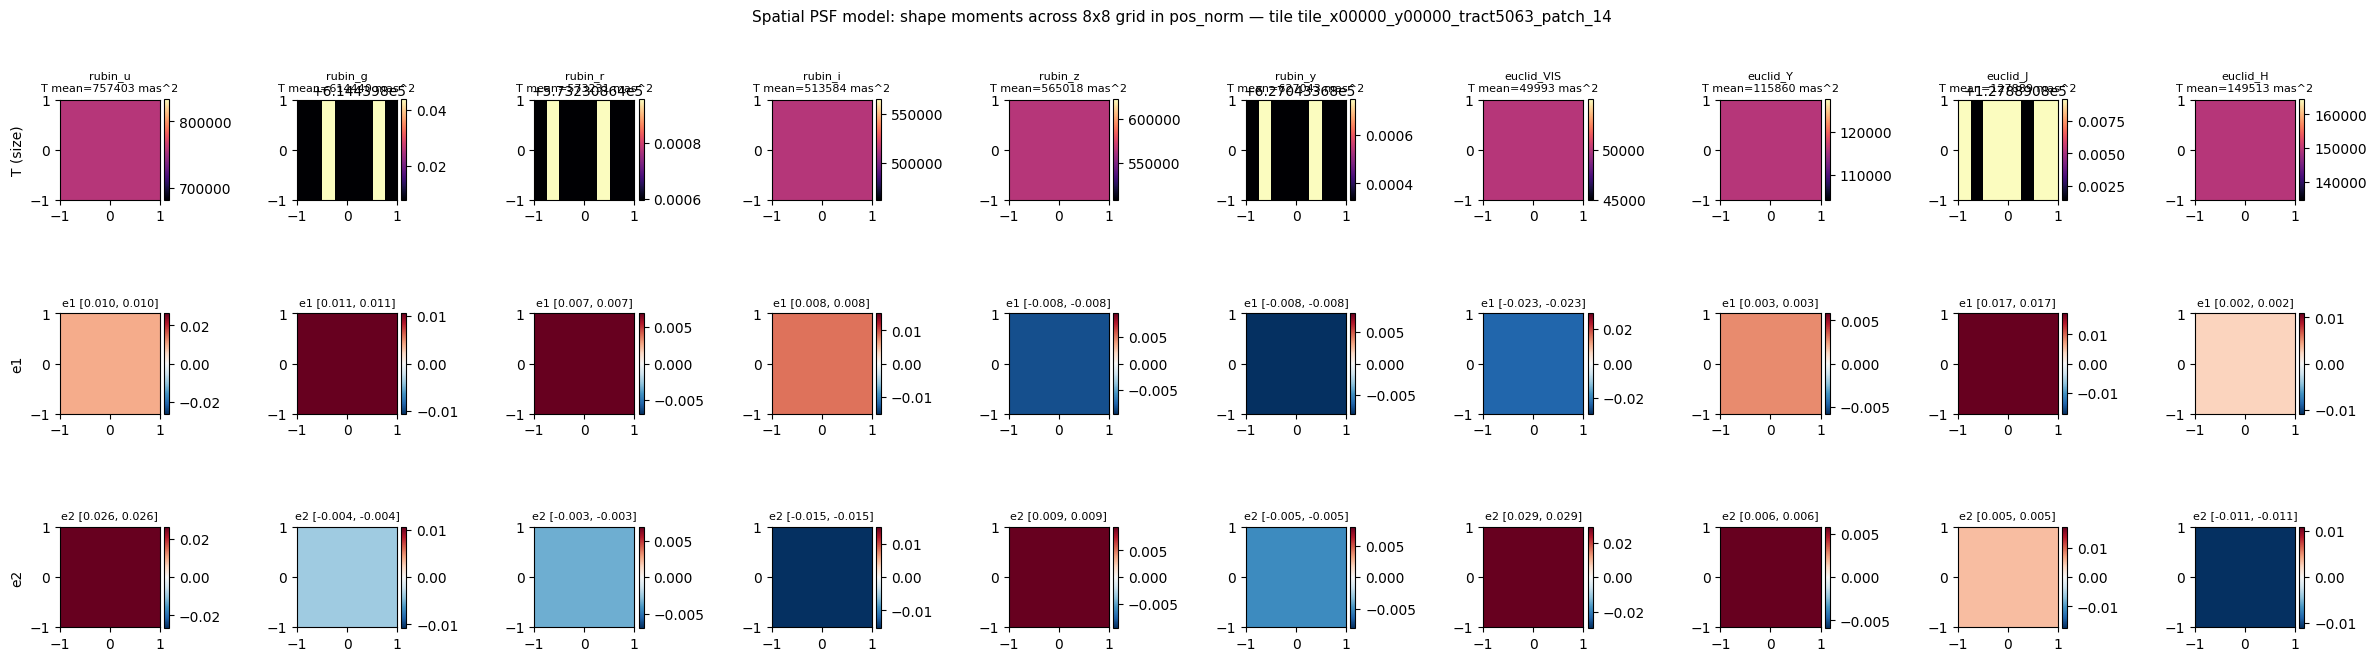

In [14]:
GRID_N = 8

xs = np.linspace(-0.9, 0.9, GRID_N).astype(np.float32)
ys = np.linspace(-0.9, 0.9, GRID_N).astype(np.float32)
gx, gy = np.meshgrid(xs, ys, indexing='xy')
pos_norm_grid = np.stack([gx.ravel(), gy.ravel()], axis=-1).astype(np.float32)
n_pts = pos_norm_grid.shape[0]

vis_H, vis_W = DEMO_VIS_HW
src_pos_vis_grid = np.stack([
    vis_W * 0.5 + 0.5 * vis_W * gx.ravel(),
    vis_H * 0.5 + 0.5 * vis_H * gy.ravel(),
], axis=-1).astype(np.float32)

def _moments_oversampled(epsfs):
    """T (in oversampled pix^2), e1, e2 from a stack of unit-flux ePSFs."""
    P = epsfs.shape[-1]
    c = (P - 1) / 2.0
    yy, xx = np.indices((P, P), dtype=np.float64)
    dx = xx - c; dy = yy - c
    norm = epsfs.sum(axis=(1, 2)).clip(min=1e-12)
    Qxx = (epsfs * dx * dx).sum(axis=(1, 2)) / norm
    Qyy = (epsfs * dy * dy).sum(axis=(1, 2)) / norm
    Qxy = (epsfs * dx * dy).sum(axis=(1, 2)) / norm
    T = Qxx + Qyy
    e1 = (Qxx - Qyy) / np.clip(T, 1e-12, None)
    e2 = 2.0 * Qxy / np.clip(T, 1e-12, None)
    return T, e1, e2

T_maps, e1_maps, e2_maps = [], [], []
with torch.no_grad():
    pos_norm_t = torch.from_numpy(pos_norm_grid).to(device)
    src_pos_vis_t = torch.from_numpy(src_pos_vis_grid).to(device)
    for bi, band in enumerate(HEAD_BANDS):
        band_idx = torch.full((n_pts,), bi, device=device, dtype=torch.long)
        out = head(
            pos_norm_t, band_idx,
            bottleneck=DEMO_BOTTLENECK,
            vis_stem_features=DEMO_VIS_STEM,
            source_positions_vis=src_pos_vis_t,
            fused_hw=(DEMO_BOTTLENECK.shape[-2], DEMO_BOTTLENECK.shape[-1]),
            vis_hw=DEMO_VIS_HW,
            return_dict=True,
        )
        epsfs = out['epsf'][:, 0].cpu().numpy()
        T, e1, e2 = _moments_oversampled(epsfs)
        T_maps.append(T.reshape(GRID_N, GRID_N))
        e1_maps.append(e1.reshape(GRID_N, GRID_N))
        e2_maps.append(e2.reshape(GRID_N, GRID_N))

fig, axes = plt.subplots(3, len(HEAD_BANDS), figsize=(2.4 * len(HEAD_BANDS), 7.0))
print(f"{'band':12s} {'T mean (mas^2)':>14s} {'T std/mean %':>14s} {'|e1| max':>10s} {'|e2| max':>10s}")
for bi, band in enumerate(HEAD_BANDS):
    px_mas = (BAND_PIXEL_SCALE_ARCSEC[band] / head.oversampling) * 1000.0
    T_mas = T_maps[bi] * (px_mas ** 2)
    e1 = e1_maps[bi]; e2 = e2_maps[bi]
    print(f"{band:12s} {T_mas.mean():14.0f} {T_mas.std() / max(T_mas.mean(), 1e-12) * 100:13.2f}% {np.abs(e1).max():10.4f} {np.abs(e2).max():10.4f}")

    ax = axes[0, bi]
    im = ax.imshow(T_mas, origin='lower', cmap='magma', extent=(-1, 1, -1, 1))
    ax.set_title(f'{band}\nT mean={T_mas.mean():.0f} mas^2', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    vmax_e = max(float(np.abs(e1).max()), float(np.abs(e2).max()), 1e-3)
    ax = axes[1, bi]
    im = ax.imshow(e1, origin='lower', cmap='RdBu_r', extent=(-1, 1, -1, 1), vmin=-vmax_e, vmax=vmax_e)
    ax.set_title(f'e1 [{e1.min():.3f}, {e1.max():.3f}]', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[2, bi]
    im = ax.imshow(e2, origin='lower', cmap='RdBu_r', extent=(-1, 1, -1, 1), vmin=-vmax_e, vmax=vmax_e)
    ax.set_title(f'e2 [{e2.min():.3f}, {e2.max():.3f}]', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for row, name in enumerate(['T (size)', 'e1', 'e2']):
    axes[row, 0].set_ylabel(name)
fig.suptitle(
    f"Spatial PSF model: shape moments across {GRID_N}x{GRID_N} grid in pos_norm — tile {DEMO_TILE_ID}",
    fontsize=11,
)
plt.tight_layout(); plt.show()

## 12. Per-band residual distributions across held-out stars

For each band, take up to 200 highest-SNR Gaia stamps, run the head, fit
flux + background analytically per stamp, and compute:

- per-stamp median **|chi|** = |residual| / RMS,
- relative size residual **dT/T** where T = Q11 + Q22 (unweighted second moments inside a 6 px aperture, after background subtraction),
- ellipticity residuals **d e1**, **d e2** with e1 = (Q11 − Q22)/T, e2 = 2 Q12/T.

The summary table prints per-band medians; the histograms show the full
distributions. Tails matter as much as medians: a tight median with heavy
tails means a few stars dominate downstream applications.

Encoding 56 val tiles for residual histograms...



band            N   med |chi|   med |dT/T|   med |de1|   med |de2|
rubin_u        90       0.704       0.0116      0.0174      0.0138
rubin_g       109       1.217       0.0047      0.0029      0.0034
rubin_r       109       1.820       0.0035      0.0050      0.0044
rubin_i       109       1.520       0.0060      0.0134      0.0096
rubin_z       109       1.525       0.0092      0.0038      0.0028
rubin_y       109       0.823       0.0082      0.0067      0.0045
euclid_VIS    122       0.873       0.0227      0.0127      0.0072
euclid_Y      116       0.489       0.0231      0.0132      0.0118
euclid_J      115       0.737       0.0252      0.0168      0.0135
euclid_H      116       0.777       0.0133      0.0098      0.0087


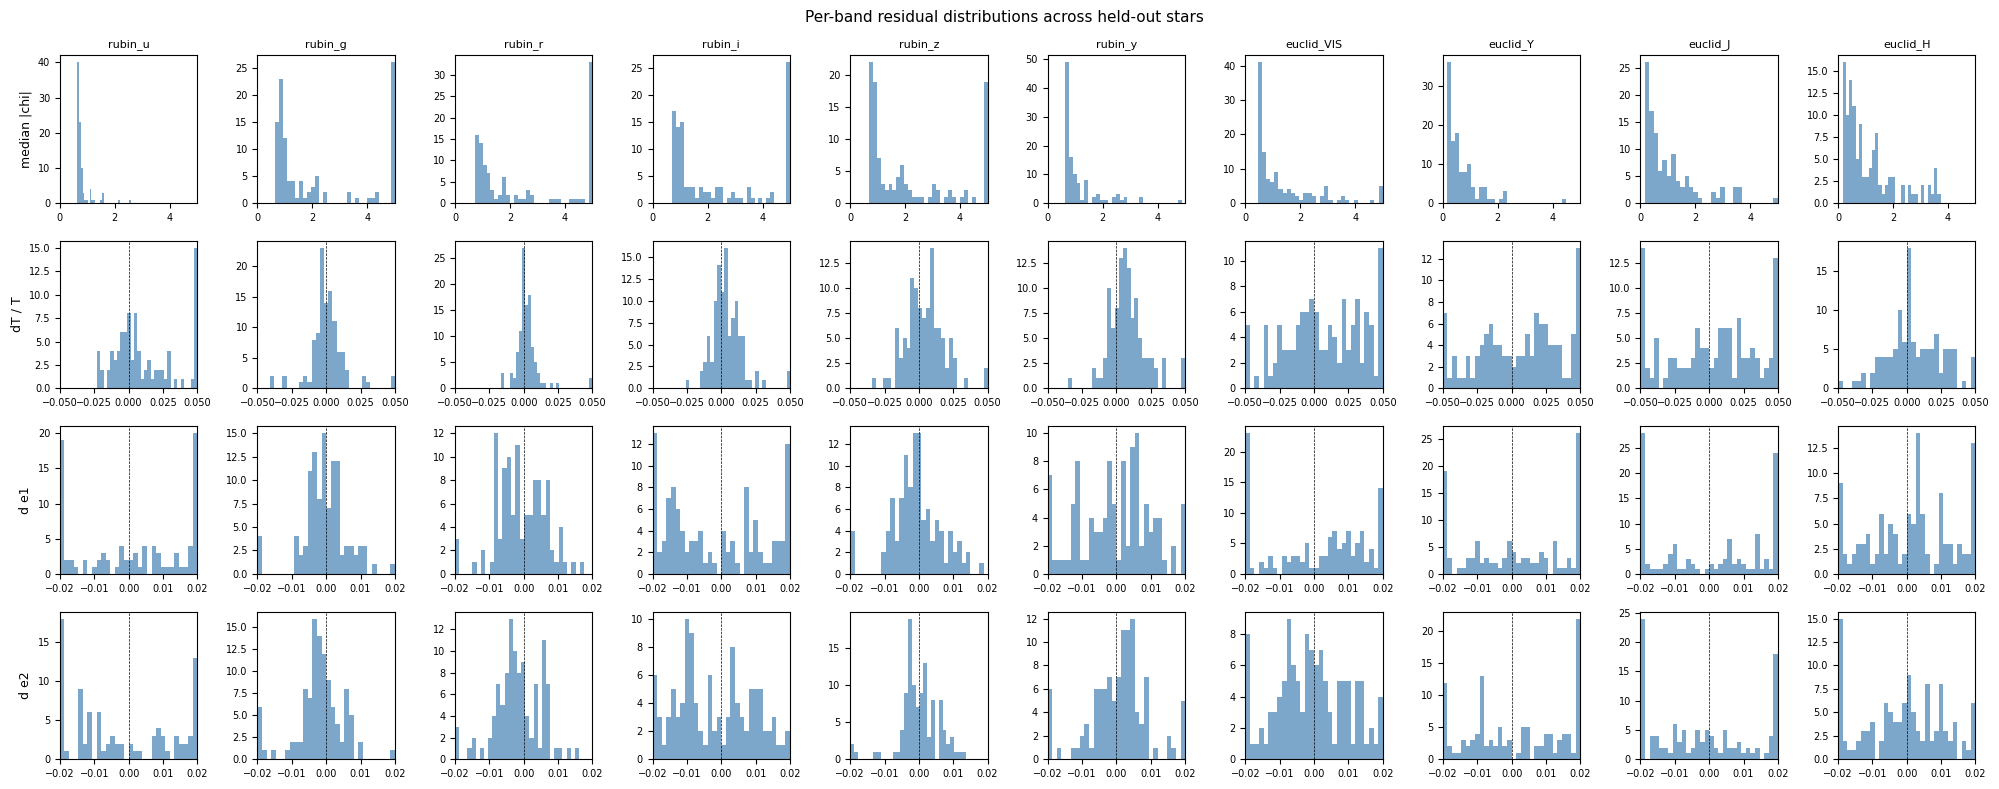

In [15]:
N_PER_BAND = 200

def _shape_moments_np(img, frac_xy=None, aperture_pix=6.0):
    """Aperture-weighted unweighted second moments per stamp [N,H,W]. Returns T, e1, e2 [N]."""
    if img.ndim == 4:
        img = img[:, 0]
    N, H, W = img.shape
    yy = np.arange(H, dtype=np.float64).reshape(1, H, 1)
    xx = np.arange(W, dtype=np.float64).reshape(1, 1, W)
    if frac_xy is None:
        cx = float(W // 2); cy = float(H // 2)
        dx = xx - cx; dy = yy - cy
    else:
        cx = (W // 2) + frac_xy[:, 0].reshape(N, 1, 1).astype(np.float64)
        cy = (H // 2) + frac_xy[:, 1].reshape(N, 1, 1).astype(np.float64)
        dx = xx - cx; dy = yy - cy
    r2 = dx * dx + dy * dy
    mask = (r2 <= aperture_pix ** 2).astype(np.float64)
    w = mask * np.clip(img, 0.0, None)
    norm = w.reshape(N, -1).sum(axis=1).clip(min=1e-12)
    Qxx = (w * dx * dx).reshape(N, -1).sum(axis=1) / norm
    Qyy = (w * dy * dy).reshape(N, -1).sum(axis=1) / norm
    Qxy = (w * dx * dy).reshape(N, -1).sum(axis=1) / norm
    T = (Qxx + Qyy).clip(min=1e-12)
    e1 = (Qxx - Qyy) / T
    e2 = 2.0 * Qxy / T
    return T, e1, e2

# Collect up to N_PER_BAND highest-SNR stars per band, grouped by tile
records_by_tile_full = {}
for bi, band in enumerate(HEAD_BANDS):
    p = TRAIN_DIR / f"{band}.npz"
    if not p.exists():
        continue
    d = np.load(p, allow_pickle=False)
    finite = (np.isfinite(d['stamps']).mean(axis=(1, 2)) > 0.95) & np.isfinite(d['snr']) & _heldout_tile_mask(d)
    valid_idx = np.where(finite)[0]
    n_pick = min(N_PER_BAND, valid_idx.size)
    order = valid_idx[np.argsort(d['snr'][valid_idx])[::-1][:n_pick]]
    for k in order:
        tile = str(d['tile_id'][k])
        if tile not in TILE_PATH:
            continue
        records_by_tile_full.setdefault(tile, []).append({
            'band': band, 'band_idx': bi,
            'stamp': d['stamps'][k].astype(np.float32),
            'rms': d['rms'][k].astype(np.float32),
            'frac_xy': d['frac_xy'][k].astype(np.float32),
            'pos_norm': d['pos_norm'][k].astype(np.float32),
            'pos_pix': d['pos_pix'][k].astype(np.float32),
            'pos_vis_pix': _pos_vis_from_npz(d, k, bi),
            'snr': float(d['snr'][k]),
        })

# Per-band residual arrays
per_band_res = {b: {'chi_med': [], 'dT_rel': [], 'de1': [], 'de2': [], 'snr': []} for b in HEAD_BANDS}
n_rubin = len(HEAD_RUBIN_BANDS)
print(f"Encoding {len(records_by_tile_full)} val tiles for residual histograms...")
for tile_id, recs in records_by_tile_full.items():
    rubin_path, euclid_path = TILE_PATH[tile_id]
    with torch.no_grad():
        ctx_imgs, ctx_rms, _, _ = load_tile_data(rubin_path, euclid_path, device)
        vis_img = ctx_imgs['euclid_VIS']; vis_rms = ctx_rms['euclid_VIS']
        bn = frozen.encoder(ctx_imgs, ctx_rms)['bottleneck']
        stem = frozen.vis_stem(vis_img, vis_rms)
        H, W = vis_img.shape[-2:]
        pos_norm = torch.tensor(np.stack([r['pos_norm'] for r in recs]), device=device)
        band_idx = torch.tensor([r['band_idx'] for r in recs], device=device, dtype=torch.long)
        frac_xy = torch.tensor(np.stack([r['frac_xy'] for r in recs]), device=device)
        src_pos_vis = _source_positions_vis_from_records(recs)
        out = head(
            pos_norm, band_idx,
            bottleneck=bn, vis_stem_features=stem,
            source_positions_vis=torch.tensor(src_pos_vis, device=device),
            fused_hw=(bn.shape[-2], bn.shape[-1]), vis_hw=(H, W),
            return_dict=True,
        )
        stamp_size = recs[0]['stamp'].shape[-1]
        native = head.render_at_native(out['epsf'], frac_xy, stamp_size=stamp_size).squeeze(1)
        # Analytic flux + bg per stamp
        stamps_t = torch.from_numpy(np.stack([r['stamp'] for r in recs])).to(device)
        rms_t = torch.from_numpy(np.stack([r['rms'] for r in recs])).to(device)
        weight = 1.0 / rms_t.clamp(min=1e-6).pow(2)
        a = (weight * native * native).flatten(1).sum(dim=1)
        b = (weight * native).flatten(1).sum(dim=1)
        c = weight.flatten(1).sum(dim=1)
        d_ = (weight * native * stamps_t).flatten(1).sum(dim=1)
        e_ = (weight * stamps_t).flatten(1).sum(dim=1)
        det = (a * c - b * b).clamp_min(1e-12)
        flux = ((d_ * c - b * e_) / det).clamp_min(0.0)
        bg = (a * e_ - b * d_) / det
        model = flux.view(-1, 1, 1) * native + bg.view(-1, 1, 1)
        chi = (stamps_t - model) / rms_t.clamp(min=1e-6)
        chi_med = chi.abs().flatten(1).median(dim=1).values.cpu().numpy()
        data_bs = (stamps_t - bg.view(-1, 1, 1)).cpu().numpy()
        model_bs = (flux.view(-1, 1, 1) * native).cpu().numpy()
        frac_xy_np = frac_xy.cpu().numpy()
    T_d, e1_d, e2_d = _shape_moments_np(data_bs, frac_xy_np)
    T_m, e1_m, e2_m = _shape_moments_np(model_bs, frac_xy_np)
    for k, r in enumerate(recs):
        b = r['band']
        per_band_res[b]['chi_med'].append(float(chi_med[k]))
        per_band_res[b]['dT_rel'].append(float((T_d[k] - T_m[k]) / max(T_d[k], 1e-12)))
        per_band_res[b]['de1'].append(float(e1_d[k] - e1_m[k]))
        per_band_res[b]['de2'].append(float(e2_d[k] - e2_m[k]))
        per_band_res[b]['snr'].append(float(r['snr']))

# Plot 4 metric rows × bands cols of histograms
metric_rows = [
    ('chi_med', 'median |chi|', (0.0, 5.0)),
    ('dT_rel', 'dT / T',        (-0.05, 0.05)),
    ('de1',    'd e1',          (-0.02, 0.02)),
    ('de2',    'd e2',          (-0.02, 0.02)),
]
fig, axes = plt.subplots(len(metric_rows), len(HEAD_BANDS),
                         figsize=(2.0 * len(HEAD_BANDS), 8.0))
print()
print(f"{'band':12s} {'N':>4s}  {'med |chi|':>10s}  {'med |dT/T|':>11s}  {'med |de1|':>10s}  {'med |de2|':>10s}")
for bi, band in enumerate(HEAD_BANDS):
    res = per_band_res[band]
    n = len(res['chi_med'])
    if n == 0:
        for ri in range(len(metric_rows)):
            axes[ri, bi].set_visible(False)
        continue
    chi_arr = np.array(res['chi_med'])
    dT_arr  = np.array(res['dT_rel'])
    de1_arr = np.array(res['de1'])
    de2_arr = np.array(res['de2'])
    print(f"{band:12s} {n:4d}  {np.median(chi_arr):10.3f}  {np.median(np.abs(dT_arr)):11.4f}  {np.median(np.abs(de1_arr)):10.4f}  {np.median(np.abs(de2_arr)):10.4f}")
    for ri, (key, label, xlim) in enumerate(metric_rows):
        ax = axes[ri, bi]
        arr = np.array(res[key])
        ax.hist(np.clip(arr, *xlim), bins=30, color='steelblue', alpha=0.7)
        if ri > 0:
            ax.axvline(0, color='k', lw=0.5, ls='--')
        ax.set_title(band if ri == 0 else '', fontsize=8)
        ax.set_xlim(xlim)
        if bi == 0:
            ax.set_ylabel(label, fontsize=9)
        ax.tick_params(labelsize=7)
fig.suptitle('Per-band residual distributions across held-out stars', fontsize=11)
plt.tight_layout(); plt.show()

## 13. Residual trends vs SNR

Re-uses the per-star residuals computed in section 8 and bins by SNR. For
each band, plots median ± 16/84 percentile of dT/T, d e1, d e2 in 6
log-spaced SNR bins. A slope means the model has a brightness-dependent
bias (size or shape) — usually a sign of unmodelled detector effects (e.g.
brighter-fatter, charge diffusion). A flat line across SNR is the goal.

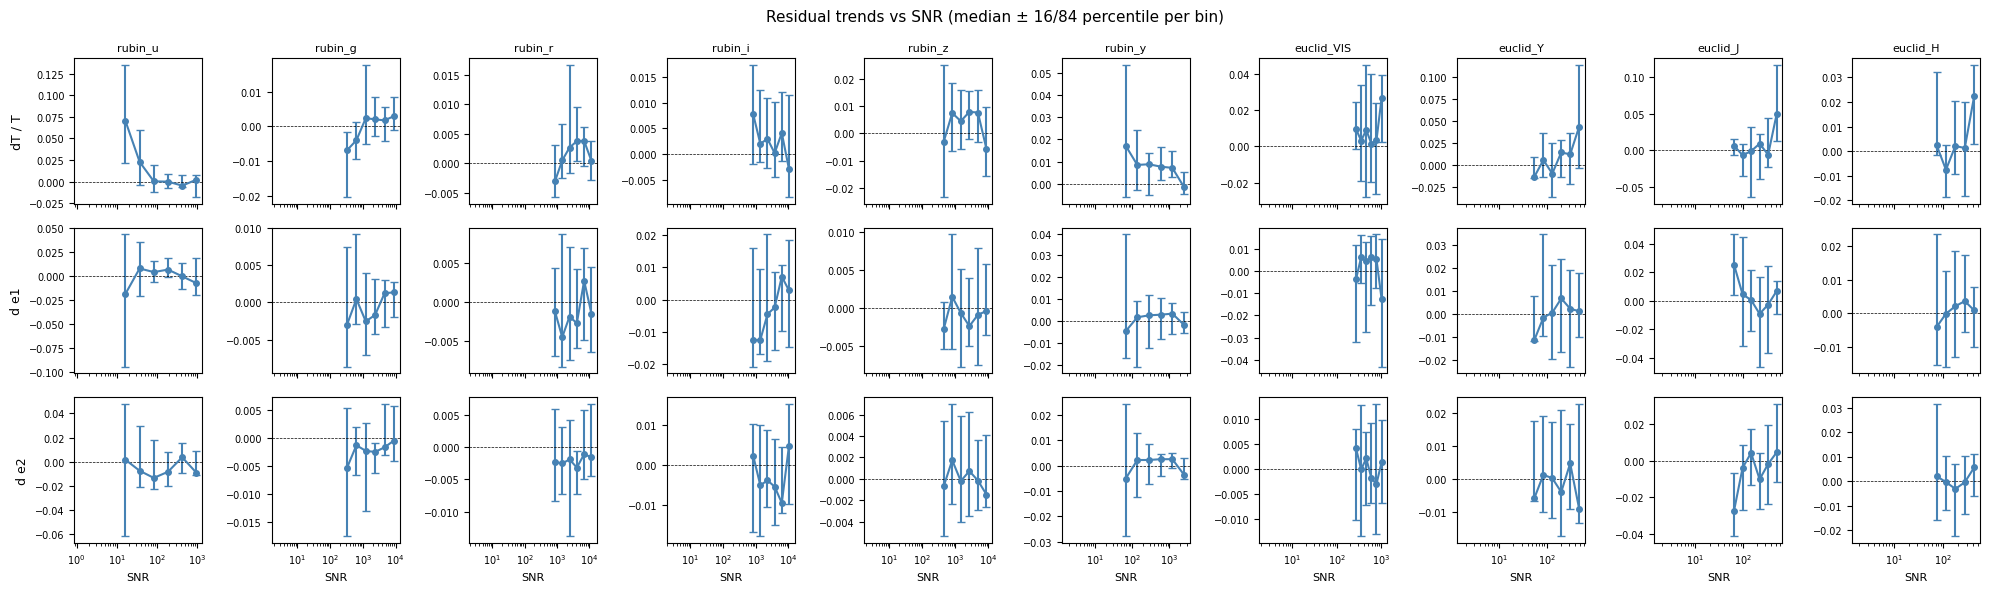

In [16]:
N_BINS = 6

fig, axes = plt.subplots(3, len(HEAD_BANDS),
                         figsize=(2.0 * len(HEAD_BANDS), 6.0), sharex='col')
metrics = [('dT_rel', 'dT / T'), ('de1', 'd e1'), ('de2', 'd e2')]
for bi, band in enumerate(HEAD_BANDS):
    res = per_band_res[band]
    if len(res['snr']) < N_BINS:
        for ri in range(3):
            axes[ri, bi].set_visible(False)
        continue
    snr = np.array(res['snr'])
    log_snr = np.log10(snr.clip(min=1.0))
    edges = np.linspace(log_snr.min(), log_snr.max(), N_BINS + 1)
    centers = 0.5 * (edges[1:] + edges[:-1])
    for ri, (key, label) in enumerate(metrics):
        arr = np.array(res[key])
        meds, lo, hi = [], [], []
        for k in range(N_BINS):
            in_bin = (log_snr >= edges[k]) & (log_snr < edges[k + 1] if k < N_BINS - 1 else log_snr <= edges[k + 1])
            if in_bin.sum() < 3:
                meds.append(np.nan); lo.append(np.nan); hi.append(np.nan)
                continue
            meds.append(np.median(arr[in_bin]))
            lo.append(np.percentile(arr[in_bin], 16))
            hi.append(np.percentile(arr[in_bin], 84))
        meds = np.array(meds); lo = np.array(lo); hi = np.array(hi)
        ax = axes[ri, bi]
        ax.errorbar(10 ** centers, meds,
                    yerr=[meds - lo, hi - meds],
                    fmt='o-', ms=4, capsize=3, color='steelblue')
        ax.axhline(0, color='k', lw=0.5, ls='--')
        ax.set_xscale('log')
        ax.tick_params(labelsize=7)
        if ri == 0:
            ax.set_title(band, fontsize=8)
        if bi == 0:
            ax.set_ylabel(label, fontsize=9)
        if ri == 2:
            ax.set_xlabel('SNR', fontsize=8)
fig.suptitle('Residual trends vs SNR (median ± 16/84 percentile per bin)',
             fontsize=11)
plt.tight_layout(); plt.show()

## 14. Per-star residual chi stack (model evaluated at each star's actual position)

For each band, take up to 200 highest-SNR Gaia stars. For each star
**individually**, render the head at that star's `pos_norm` + `frac_xy`,
solve flux + background analytically, and form `chi = (data - model) / RMS`.
Then shift each chi stamp by `-frac_xy` to align centroids on the integer
pixel grid and median-stack.

This is the fair version of "empirical vs model": both sides use each
star's true position, no peak normalisation, results in chi units
(N(0,1) if the model is correct on average). The plotted maps:

- **median chi** — any systematic bias (positive or negative); should be ≈ 0.
- **median |chi|** — where the model fits well per pixel; ≈ 0.674 (median of |N(0,1)|) is the noise floor.
- **p99 |chi|** — worst-case per pixel across the star sample; tells you about the long tail.

Summary table prints median |chi| over: all pixels, core (r<3 px), wings (5≤r<10 px).

Encoding 56 tiles for residual chi stack...

band            N   med |chi| all   core (r<3)   wing (5≤r<10)
rubin_u        56           0.543        0.969           0.573
rubin_g        33           0.626        2.217           0.625
rubin_r        10           0.673        4.189           0.656
rubin_i         7           0.609        2.919           0.617
rubin_z        20           0.552        2.265           0.529
rubin_y        71           0.543        1.099           0.524
euclid_VIS    121           0.823        4.324           0.908
euclid_Y      115           0.450        2.296           0.561
euclid_J      115           0.666        2.393           0.745
euclid_H      115           0.703        2.021           0.821


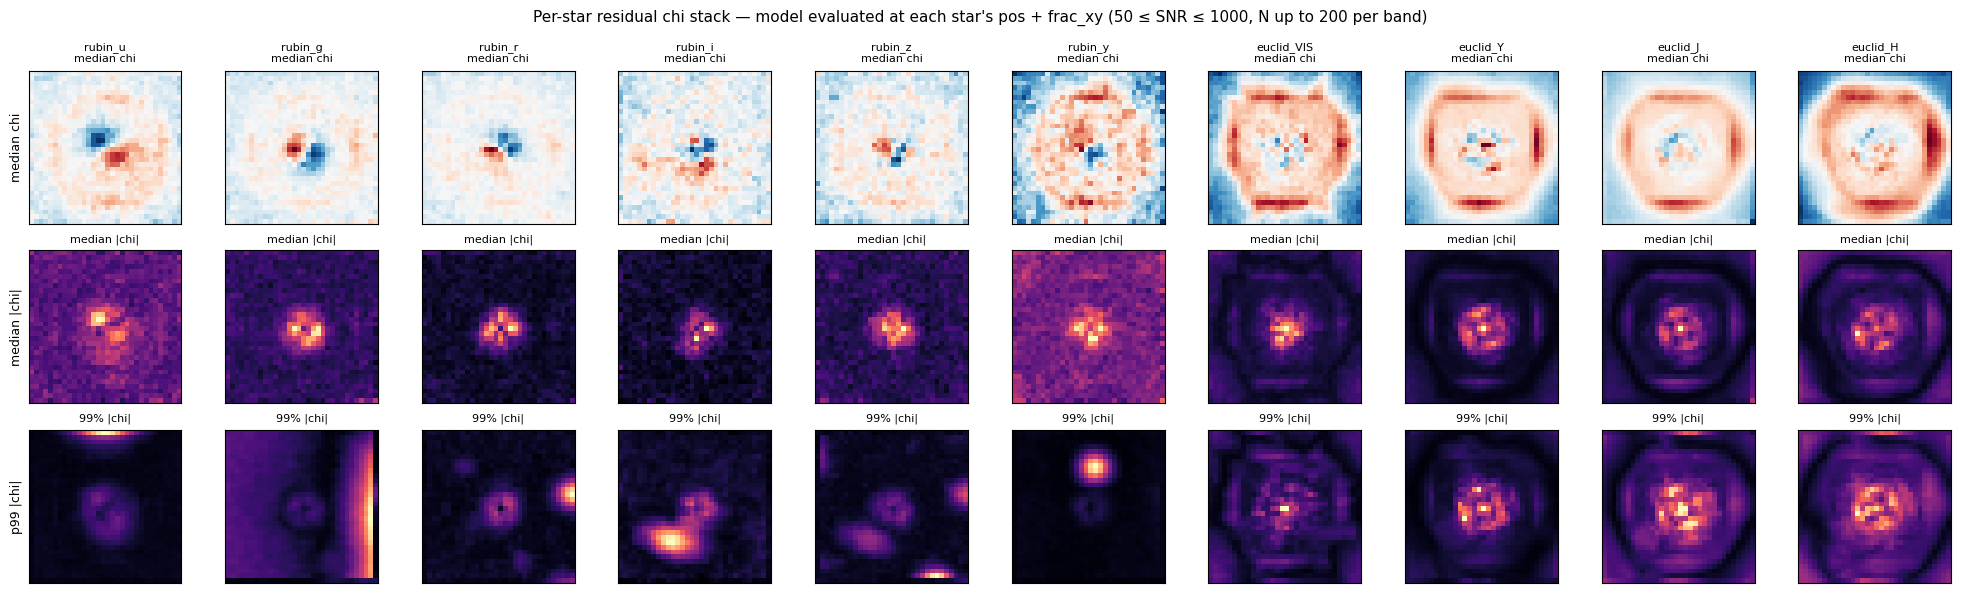

In [17]:
from scipy.ndimage import shift as ndshift

SNR_MIN_RES = 50.0
SNR_MAX_RES = 1000.0
N_MAX_RES = 200
RNG_RES = np.random.default_rng(17)

# Random mid-SNR stars per band, grouped by tile. Avoid letting the stack be
# dominated by the same extreme-SNR stars that drive square/core artifacts.
records_by_tile_res = {}
for bi, band in enumerate(HEAD_BANDS):
    p = TRAIN_DIR / f"{band}.npz"
    if not p.exists():
        continue
    d = np.load(p, allow_pickle=False)
    finite = (np.isfinite(d['stamps']).mean(axis=(1, 2)) > 0.95) & np.isfinite(d['snr']) & _heldout_tile_mask(d)
    snr_ok = (d['snr'] >= SNR_MIN_RES) & (d['snr'] <= SNR_MAX_RES)
    sel = np.where(finite & snr_ok)[0]
    if len(sel) > N_MAX_RES:
        sel = RNG_RES.choice(sel, size=N_MAX_RES, replace=False)
    for k in sel:
        tile = str(d['tile_id'][k])
        if tile not in TILE_PATH:
            continue
        records_by_tile_res.setdefault(tile, []).append({
            'band': band, 'band_idx': bi,
            'stamp':   d['stamps'][k].astype(np.float32),
            'rms':     d['rms'][k].astype(np.float32),
            'frac_xy': d['frac_xy'][k].astype(np.float32),
            'pos_norm': d['pos_norm'][k].astype(np.float32),
            'pos_pix': d['pos_pix'][k].astype(np.float32),
            'pos_vis_pix': _pos_vis_from_npz(d, k, bi),
        })

# Per-star chi maps, centroid-aligned via -frac_xy shift. NaN padding avoids
# painting artificial zero-valued borders into the median stack.
chi_by_band = {b: [] for b in HEAD_BANDS}
n_rubin = len(HEAD_RUBIN_BANDS)
print(f"Encoding {len(records_by_tile_res)} tiles for residual chi stack...")
for tile_id, recs in records_by_tile_res.items():
    rubin_path, euclid_path = TILE_PATH[tile_id]
    with torch.no_grad():
        ctx_imgs, ctx_rms, _, _ = load_tile_data(rubin_path, euclid_path, device)
        vis_img = ctx_imgs['euclid_VIS']; vis_rms = ctx_rms['euclid_VIS']
        bn = frozen.encoder(ctx_imgs, ctx_rms)['bottleneck']
        stem = frozen.vis_stem(vis_img, vis_rms)
        H, W = vis_img.shape[-2:]
        pos_norm = torch.tensor(np.stack([r['pos_norm'] for r in recs]), device=device)
        band_idx = torch.tensor([r['band_idx'] for r in recs], device=device, dtype=torch.long)
        frac_xy = torch.tensor(np.stack([r['frac_xy'] for r in recs]), device=device)
        src_pos_vis = _source_positions_vis_from_records(recs)
        out = head(
            pos_norm, band_idx,
            bottleneck=bn, vis_stem_features=stem,
            source_positions_vis=torch.tensor(src_pos_vis, device=device),
            fused_hw=(bn.shape[-2], bn.shape[-1]), vis_hw=(H, W),
            return_dict=True,
        )
        stamp_size = recs[0]['stamp'].shape[-1]
        native = head.render_at_native(out['epsf'], frac_xy, stamp_size=stamp_size).squeeze(1)
        stamps_t = torch.from_numpy(np.stack([r['stamp'] for r in recs])).to(device)
        rms_t = torch.from_numpy(np.stack([r['rms'] for r in recs])).to(device)
        weight = 1.0 / rms_t.clamp(min=1e-6).pow(2)
        a = (weight * native * native).flatten(1).sum(dim=1)
        b = (weight * native).flatten(1).sum(dim=1)
        c = weight.flatten(1).sum(dim=1)
        d_ = (weight * native * stamps_t).flatten(1).sum(dim=1)
        e_ = (weight * stamps_t).flatten(1).sum(dim=1)
        det = (a * c - b * b).clamp_min(1e-12)
        flux = ((d_ * c - b * e_) / det).clamp_min(0.0)
        bg = (a * e_ - b * d_) / det
        model = flux.view(-1, 1, 1) * native + bg.view(-1, 1, 1)
        chi = ((stamps_t - model) / rms_t.clamp(min=1e-6)).cpu().numpy()
        frac_xy_np = frac_xy.cpu().numpy()
    for k, r in enumerate(recs):
        ch_shifted = ndshift(chi[k], shift=(-float(frac_xy_np[k, 1]),
                                              -float(frac_xy_np[k, 0])),
                              order=1, mode='constant', cval=np.nan)
        chi_by_band[r['band']].append(ch_shifted)

# Plot 3 maps per band: median chi, median |chi|, p99 |chi|
fig, axes = plt.subplots(3, len(HEAD_BANDS),
                         figsize=(2.0 * len(HEAD_BANDS), 6.0))
print()
print(f"{'band':12s} {'N':>4s}  {'med |chi| all':>14s}  {'core (r<3)':>11s}  {'wing (5≤r<10)':>14s}")
for bi, band in enumerate(HEAD_BANDS):
    arr = chi_by_band[band]
    if not arr:
        for r in range(3):
            axes[r, bi].set_visible(False)
        continue
    arr = np.stack(arr)
    chi_med = np.nanmedian(arr, axis=0)
    chi_abs_med = np.nanmedian(np.abs(arr), axis=0)
    chi_abs_p99 = np.nanpercentile(np.abs(arr), 99, axis=0)

    P = chi_abs_med.shape[-1]
    yy, xx = np.indices(chi_abs_med.shape)
    r_pix = np.hypot(xx - P // 2, yy - P // 2)
    core = r_pix < 3.0
    wing = (r_pix >= 5.0) & (r_pix < 10.0)
    print(f"{band:12s} {arr.shape[0]:4d}  "
          f"{float(np.nanmedian(np.abs(arr))):>14.3f}  "
          f"{float(np.nanmedian(np.abs(arr)[:, core])):>11.3f}  "
          f"{float(np.nanmedian(np.abs(arr)[:, wing])):>14.3f}")

    vmax_signed = max(float(np.abs(chi_med).max()), 0.5)
    axes[0, bi].imshow(chi_med, cmap='RdBu_r', vmin=-vmax_signed, vmax=vmax_signed)
    axes[0, bi].set_title(f"{band}\nmedian chi", fontsize=8)
    axes[1, bi].imshow(chi_abs_med, cmap='magma',
                       vmin=0.0, vmax=max(float(chi_abs_med.max()), 1.0))
    axes[1, bi].set_title('median |chi|', fontsize=8)
    axes[2, bi].imshow(chi_abs_p99, cmap='magma',
                       vmin=0.0, vmax=max(float(chi_abs_p99.max()), 3.0))
    axes[2, bi].set_title('99% |chi|', fontsize=8)
    for r in range(3):
        axes[r, bi].set_xticks([]); axes[r, bi].set_yticks([])

for r, name in enumerate(['median chi', 'median |chi|', 'p99 |chi|']):
    axes[r, 0].set_ylabel(name, fontsize=9)
fig.suptitle(
    f"Per-star residual chi stack — model evaluated at each star's pos + frac_xy "
    f"({SNR_MIN_RES:g} ≤ SNR ≤ {SNR_MAX_RES:g}, N up to {N_MAX_RES} per band)",
    fontsize=11,
)
plt.tight_layout(); plt.show()

## 15. Centroid-marginalised chi stack — does the dipole survive?

Tests whether the section-14 dipole is sub-pixel centroid mis-registration.

- **(A) Empirical-bank argmax offset.** Parabolic peak fit on each band's
  empirical PSF (`EMPIRICAL_BASE_BANK`). If the base bank inherits a centroid
  bias from its training stamps, this prints a non-zero offset.

- **(B) Per-star (dx, dy) fit during evaluation.** Keep the head's predicted
  ePSF fixed, optimise (dx, dy) jointly with the analytic flux+bg solve, and
  re-make the chi stack aligned by `-(frac_xy + delta)`. If the dipole
  disappears, the diagnosis is confirmed: fix is to add per-star sub-pixel
  shift to `fit_empirical_epsf_bank.py`. The per-band median of the optimised
  delta is the inherited bias (≈ band WCS offset folded into the base PSF).

Empirical-bank centroid offset (parabolic peak fit on oversampled grid):
band            dx_nat    dy_nat   |d|_mas
rubin_u         0.8008    0.1955     164.9
rubin_g         0.2266   -0.2242      63.8
rubin_r         0.2155   -0.3770      86.8
rubin_i         0.2468   -0.5192     115.0
rubin_z         0.5185   -0.2862     118.4
rubin_y         0.5597   -0.1966     118.6
euclid_VIS      0.0089   -0.2440      24.4
euclid_Y       -1.5955   -0.2046     160.9
euclid_J       -1.2204   -0.6050     136.2
euclid_H       -1.2050   -0.1763     121.8

Refitting per-star centroid (60 Adam steps, lr=0.02)...

band            N  core before  core after  med |d|_mas  med dx mas  med dy mas
rubin_u        56        1.035       0.736         31.1        17.6        20.6
rubin_g        33        2.590       0.863         18.9       -10.7        -5.4
rubin_r        10        5.201       1.157         26.5       -13.0         6.7
rubin_i         7        3.880       1.724         18.1        -0.5        -

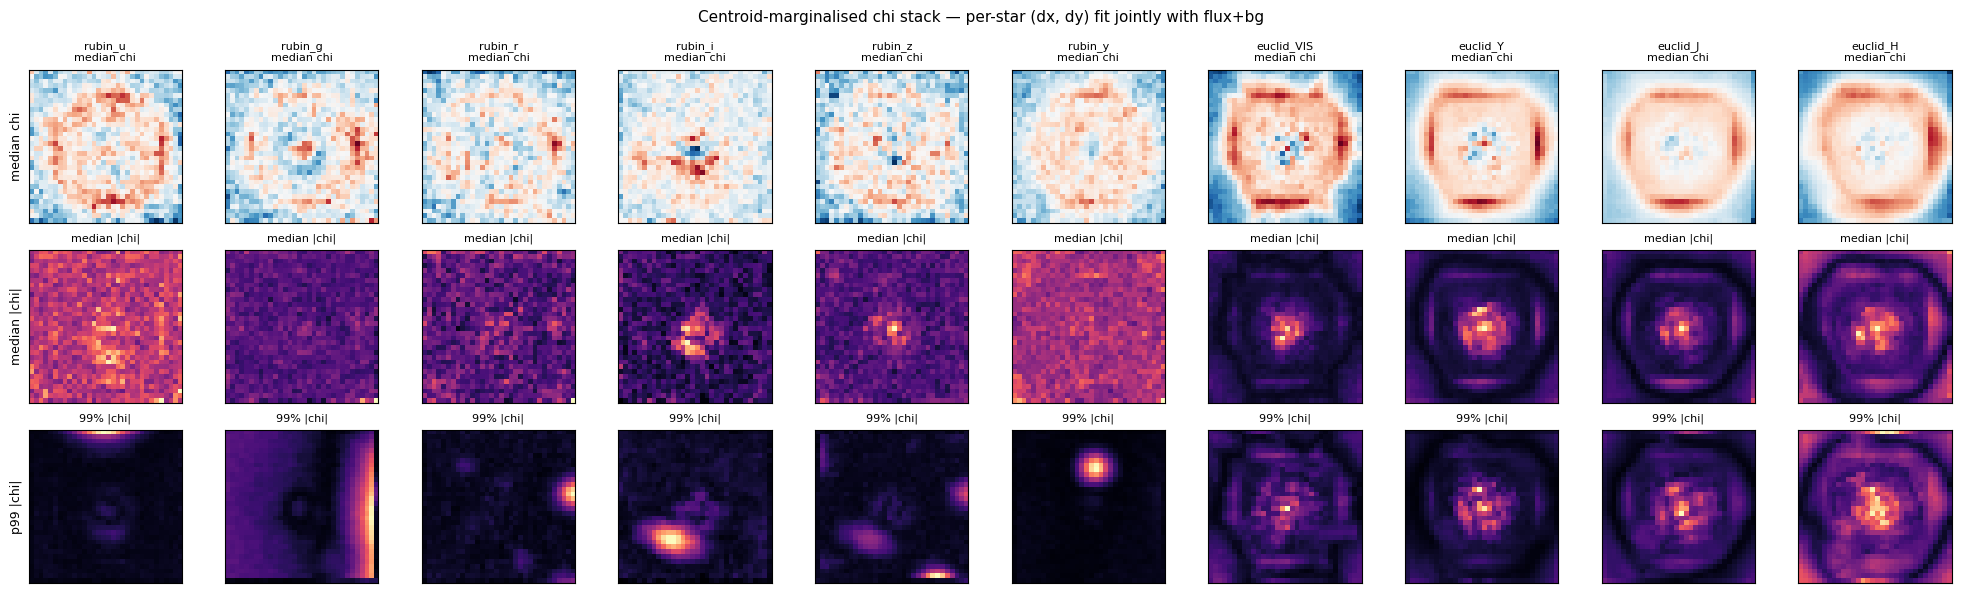

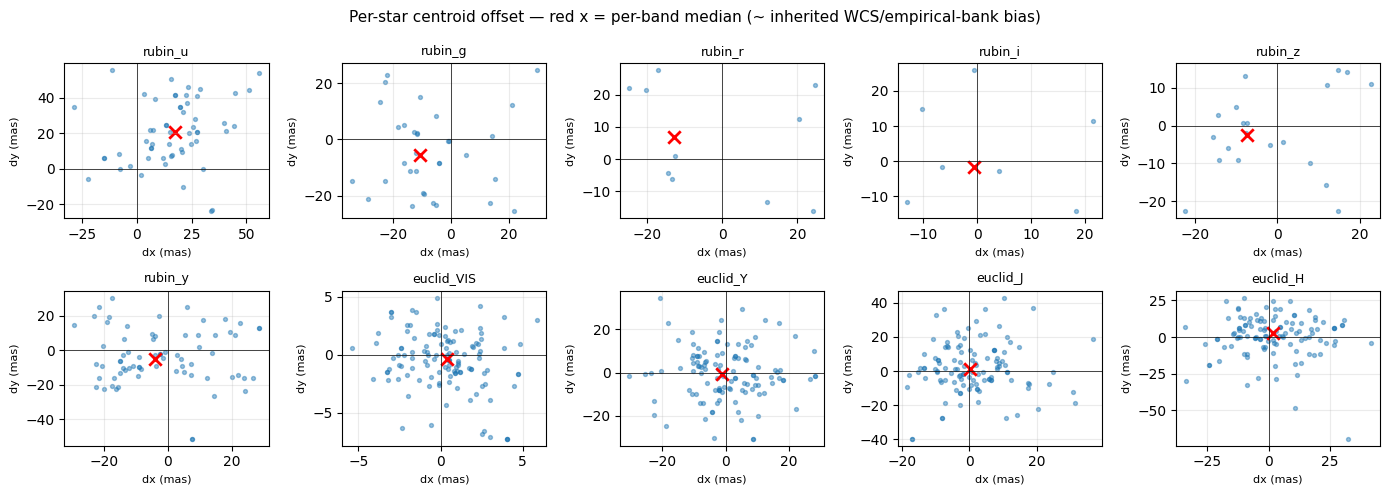

In [18]:
# (A) Empirical-bank centroid offset per band.
# Parabolic peak refinement on the oversampled ePSF -> native pixels -> mas.
print("Empirical-bank centroid offset (parabolic peak fit on oversampled grid):")
print(f"{'band':12s} {'dx_nat':>9s} {'dy_nat':>9s} {'|d|_mas':>9s}")
if EMPIRICAL_BASE_BANK is not None:
    def _parab_subpx(vm, v0, vp):
        den = 2.0 * (2.0 * v0 - vm - vp)
        return 0.0 if abs(den) < 1e-12 else float((vp - vm) / den)
    for _bi, _band in enumerate(ALL_BANDS):
        _psf = np.asarray(EMPIRICAL_BASE_BANK[_bi], dtype=np.float64)
        _P = _psf.shape[0]
        _c = (_P - 1) / 2.0
        _iy, _ix = np.unravel_index(int(np.argmax(_psf)), _psf.shape)
        _dx_sub = _parab_subpx(_psf[_iy, _ix - 1], _psf[_iy, _ix], _psf[_iy, _ix + 1]) if 0 < _ix < _P - 1 else 0.0
        _dy_sub = _parab_subpx(_psf[_iy - 1, _ix], _psf[_iy, _ix], _psf[_iy + 1, _ix]) if 0 < _iy < _P - 1 else 0.0
        _dx_nat = ((_ix - _c) + _dx_sub) / EMPIRICAL_OVERSAMPLING
        _dy_nat = ((_iy - _c) + _dy_sub) / EMPIRICAL_OVERSAMPLING
        _dr_mas = float(np.hypot(_dx_nat, _dy_nat) * BAND_PIXEL_SCALE_ARCSEC[_band] * 1000.0)
        print(f"{_band:12s} {_dx_nat:9.4f} {_dy_nat:9.4f} {_dr_mas:9.1f}")
else:
    print("  EMPIRICAL_BASE_BANK is None; run section 3 first.")
print()

# (B) Per-star (dx, dy) joint fit with analytic flux+bg.
# Reuses the section-14 sample (records_by_tile_res) and the foundation head.
N_FIT_ITERS = 60
LR_DELTA = 0.02

chi_by_band_corr = {b: [] for b in HEAD_BANDS}
delta_by_band = {b: [] for b in HEAD_BANDS}
core_before_after = {b: {"before": [], "after": []} for b in HEAD_BANDS}

print(f"Refitting per-star centroid ({N_FIT_ITERS} Adam steps, lr={LR_DELTA})...")
for tile_id, recs in records_by_tile_res.items():
    rubin_path, euclid_path = TILE_PATH[tile_id]
    with torch.no_grad():
        ctx_imgs, ctx_rms, _, _ = load_tile_data(rubin_path, euclid_path, device)
        vis_img = ctx_imgs['euclid_VIS']; vis_rms = ctx_rms['euclid_VIS']
        bn = frozen.encoder(ctx_imgs, ctx_rms)['bottleneck']
        stem = frozen.vis_stem(vis_img, vis_rms)
        H, W = vis_img.shape[-2:]
        pos_norm = torch.tensor(np.stack([r['pos_norm'] for r in recs]), device=device)
        band_idx_t = torch.tensor([r['band_idx'] for r in recs], device=device, dtype=torch.long)
        frac_xy = torch.tensor(np.stack([r['frac_xy'] for r in recs]), device=device)
        src_pos_vis_t = torch.tensor(_source_positions_vis_from_records(recs), device=device)
        out = head(
            pos_norm, band_idx_t,
            bottleneck=bn, vis_stem_features=stem,
            source_positions_vis=src_pos_vis_t,
            fused_hw=(bn.shape[-2], bn.shape[-1]), vis_hw=(H, W),
            return_dict=True,
        )
        epsf_fixed = out['epsf'].detach()
        stamps_t = torch.from_numpy(np.stack([r['stamp'] for r in recs])).to(device)
        rms_t = torch.from_numpy(np.stack([r['rms'] for r in recs])).to(device).clamp(min=1e-6)
        stamp_size = recs[0]['stamp'].shape[-1]

    delta = torch.zeros(len(recs), 2, device=device, requires_grad=True)
    opt = torch.optim.Adam([delta], lr=LR_DELTA)

    def _fit_and_chi(frac_total):
        native = head.render_at_native(epsf_fixed, frac_total, stamp_size=stamp_size).squeeze(1)
        weight = 1.0 / rms_t.pow(2)
        a = (weight * native * native).flatten(1).sum(dim=1)
        b = (weight * native).flatten(1).sum(dim=1)
        c = weight.flatten(1).sum(dim=1)
        d_ = (weight * native * stamps_t).flatten(1).sum(dim=1)
        e_ = (weight * stamps_t).flatten(1).sum(dim=1)
        det = (a * c - b * b).clamp_min(1e-12)
        flux = ((d_ * c - b * e_) / det).clamp_min(0.0)
        bg = (a * e_ - b * d_) / det
        model = flux.view(-1, 1, 1) * native + bg.view(-1, 1, 1)
        return model, ((stamps_t - model) / rms_t)

    with torch.no_grad():
        _, chi0 = _fit_and_chi(frac_xy)
        chi0_np = chi0.cpu().numpy()

    for _ in range(N_FIT_ITERS):
        opt.zero_grad()
        _, chi_now = _fit_and_chi(frac_xy + delta)
        (chi_now ** 2).flatten(1).mean(dim=1).sum().backward()
        opt.step()

    with torch.no_grad():
        _, chi_final = _fit_and_chi(frac_xy + delta)
        chi_final_np = chi_final.cpu().numpy()
        delta_np = delta.detach().cpu().numpy()
        frac_xy_np = frac_xy.cpu().numpy()

    _P = chi_final_np.shape[-1]
    _yy, _xx = np.indices((_P, _P))
    _core_mask = np.hypot(_xx - _P // 2, _yy - _P // 2) < 3.0
    for k, r in enumerate(recs):
        total = frac_xy_np[k] + delta_np[k]
        ch_shift = ndshift(chi_final_np[k], shift=(-float(total[1]), -float(total[0])),
                            order=1, mode='constant', cval=np.nan)
        chi_by_band_corr[r['band']].append(ch_shift)
        delta_by_band[r['band']].append(delta_np[k].astype(float))
        core_before_after[r['band']]["before"].append(float(np.nanmedian(np.abs(chi0_np[k][_core_mask]))))
        core_before_after[r['band']]["after"].append(float(np.nanmedian(np.abs(chi_final_np[k][_core_mask]))))

fig, axes = plt.subplots(3, len(HEAD_BANDS), figsize=(2.0 * len(HEAD_BANDS), 6.0))
print()
print(f"{'band':12s} {'N':>4s} {'core before':>12s} {'core after':>11s} {'med |d|_mas':>12s} {'med dx mas':>11s} {'med dy mas':>11s}")
for bi, band in enumerate(HEAD_BANDS):
    arr = chi_by_band_corr[band]
    if not arr:
        for r in range(3):
            axes[r, bi].set_visible(False)
        continue
    arr = np.stack(arr)
    chi_med = np.nanmedian(arr, axis=0)
    chi_abs_med = np.nanmedian(np.abs(arr), axis=0)
    chi_abs_p99 = np.nanpercentile(np.abs(arr), 99, axis=0)
    d_arr = np.array(delta_by_band[band])
    s_arc = BAND_PIXEL_SCALE_ARCSEC[band] * 1000.0
    dx_mas = float(np.median(d_arr[:, 0])) * s_arc
    dy_mas = float(np.median(d_arr[:, 1])) * s_arc
    dr_mas = float(np.median(np.hypot(d_arr[:, 0], d_arr[:, 1]))) * s_arc
    core_b = float(np.median(core_before_after[band]["before"]))
    core_a = float(np.median(core_before_after[band]["after"]))
    print(f"{band:12s} {arr.shape[0]:4d} {core_b:12.3f} {core_a:11.3f} {dr_mas:12.1f} {dx_mas:11.1f} {dy_mas:11.1f}")
    vmax_signed = max(float(np.abs(chi_med).max()), 0.5)
    axes[0, bi].imshow(chi_med, cmap='RdBu_r', vmin=-vmax_signed, vmax=vmax_signed)
    axes[0, bi].set_title(f"{band}\nmedian chi", fontsize=8)
    axes[1, bi].imshow(chi_abs_med, cmap='magma', vmin=0.0,
                       vmax=max(float(chi_abs_med.max()), 1.0))
    axes[1, bi].set_title('median |chi|', fontsize=8)
    axes[2, bi].imshow(chi_abs_p99, cmap='magma', vmin=0.0,
                       vmax=max(float(chi_abs_p99.max()), 3.0))
    axes[2, bi].set_title('99% |chi|', fontsize=8)
    for r in range(3):
        axes[r, bi].set_xticks([]); axes[r, bi].set_yticks([])
for r, name in enumerate(['median chi', 'median |chi|', 'p99 |chi|']):
    axes[r, 0].set_ylabel(name, fontsize=9)
fig.suptitle("Centroid-marginalised chi stack — per-star (dx, dy) fit jointly with flux+bg",
             fontsize=11)
plt.tight_layout(); plt.show()

# Per-band delta scatter (red x = median).
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for bi, band in enumerate(HEAD_BANDS):
    ax = axes[bi // 5, bi % 5]
    d_arr = np.array(delta_by_band[band])
    if d_arr.size == 0:
        ax.set_facecolor('#222'); continue
    s_arc = BAND_PIXEL_SCALE_ARCSEC[band] * 1000.0
    ax.scatter(d_arr[:, 0] * s_arc, d_arr[:, 1] * s_arc, s=8, alpha=0.45)
    ax.scatter([np.median(d_arr[:, 0]) * s_arc], [np.median(d_arr[:, 1]) * s_arc],
               s=80, color='red', marker='x', linewidths=2)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_title(band, fontsize=9)
    ax.set_xlabel('dx (mas)', fontsize=8)
    ax.set_ylabel('dy (mas)', fontsize=8)
    ax.grid(alpha=0.25)
fig.suptitle("Per-star centroid offset — red x = per-band median (~ inherited WCS/empirical-bank bias)",
             fontsize=11)
plt.tight_layout(); plt.show()

## 16. Bank-only chi stack — isolate the new empirical bank

Section 14 and 15 evaluate the **head** (`load_foundation_epsf_head(HEAD_CKPT)`),
whose checkpoint bakes in the *old* bank. To test the freshly-fit bank without
waiting for the head retrain, evaluate `EMPIRICAL_BASE_BANK_T` directly through
`EMP_RENDER_HEAD` (no foundation features, no residual basis — just the bank).

If the centroid fix worked, the Rubin median-chi dipoles should be **gone or
much weaker** here even though they persist in section 14 (which is still the
old head + old bank). Euclid wing ring will likely remain — it's a shape
problem, not a centroid problem.

held-out tiles: 79 / 790  (seed=0, val_frac=0.10)
sample: 663 stars across 56 held-out tiles (50 <= SNR <= 1000)
Bank: empirical_epsf_bank_psf_training_gaia_pm_v2_r15_centroidv2.pt

band            N med |chi| all  core (r<3) wing (5-10)  (compare to sec 14)
rubin_u        56         0.559       1.334       0.612
rubin_g        33         0.618       1.827       0.608
rubin_r        10         0.699       7.203       0.753
rubin_i         7         0.615       4.357       0.639
rubin_z        20         0.557       2.285       0.538
rubin_y        71         0.545       1.088       0.525
euclid_VIS    121         0.825       4.370       0.914
euclid_Y      115         0.455       2.450       0.580
euclid_J      115         0.676       2.836       0.771
euclid_H      115         0.714       2.434       0.859


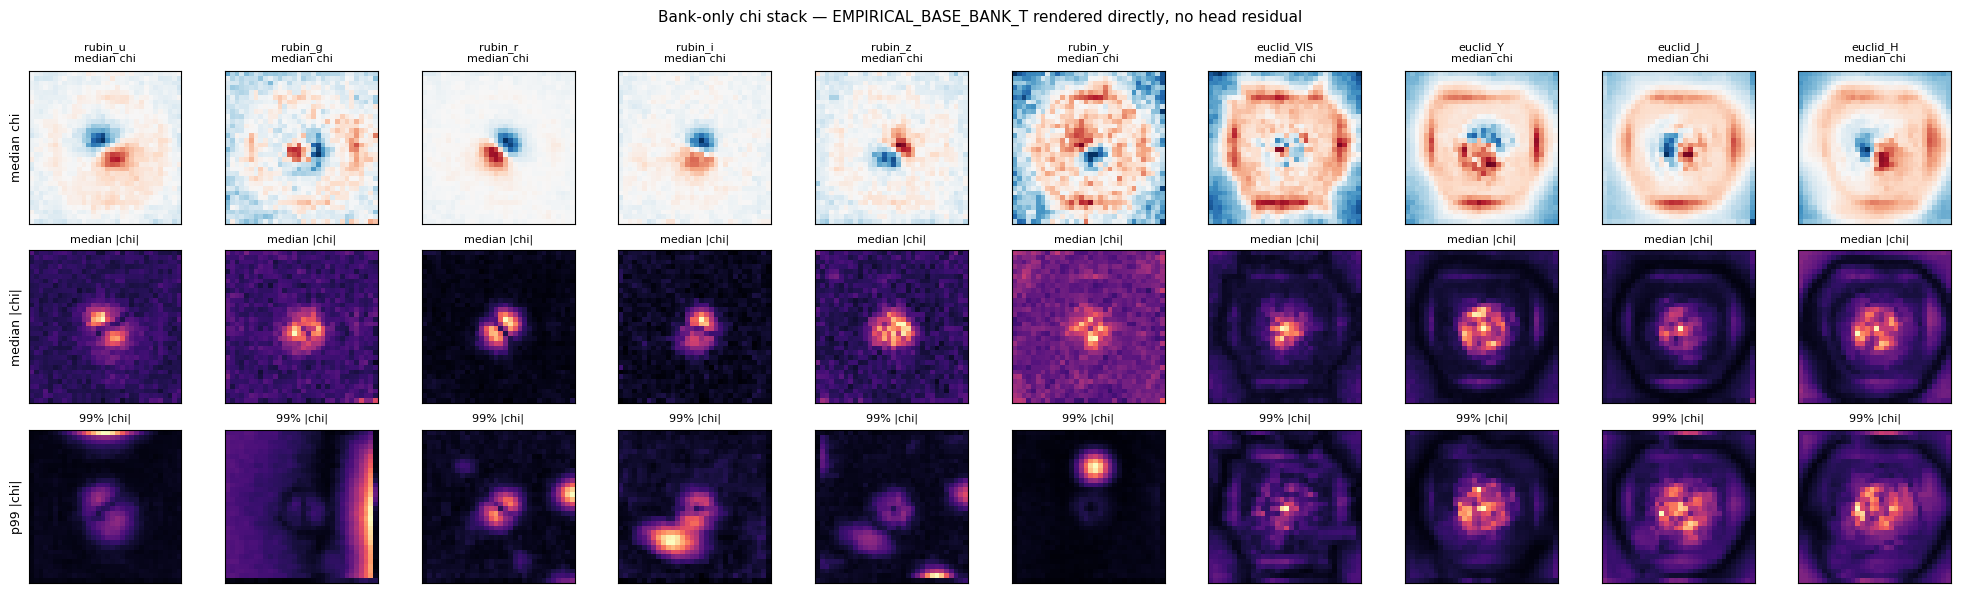

In [18]:
# Self-contained bank-only chi stack.
# Requires only cells 1 (setup) and 7 (empirical-epsf-load).
# No foundation encoder, no head — pure EMPIRICAL_BASE_BANK_T evaluation.

from scipy.ndimage import shift as ndshift
from psf.foundation_epsf_head import ALL_BANDS as HEAD_BANDS

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Derive held-out tile set from HEAD_CKPT config so it matches sec 14's split.
_ckpt_meta_for_split = torch.load(str(HEAD_CKPT), map_location="cpu", weights_only=False)
VAL_FRAC = float(_ckpt_meta_for_split.get("config", {}).get("val_frac", 0.10))
SPLIT_SEED = int(_ckpt_meta_for_split.get("config", {}).get("seed", 0))
PAIRS = discover_tile_pairs(str(RUBIN_DIR), str(EUCLID_DIR))
_train_pairs, VAL_PAIRS = split_tile_pairs(PAIRS, val_frac=VAL_FRAC, seed=SPLIT_SEED)
TILE_PATH = {tid: (rp, ep) for tid, rp, ep in PAIRS}
HELDOUT_TILE_IDS = {tid for tid, _rp, _ep in VAL_PAIRS}
print(f"held-out tiles: {len(HELDOUT_TILE_IDS)} / {len(PAIRS)}  "
      f"(seed={SPLIT_SEED}, val_frac={VAL_FRAC:.2f})")

# Build per-tile records (minimal fields — bank doesn't use pos_norm/pos_vis).
SNR_MIN_RES = 50.0
SNR_MAX_RES = 1000.0
N_MAX_RES = 200
RNG_RES = np.random.default_rng(17)

records_by_tile_bank = {}
for bi, band in enumerate(HEAD_BANDS):
    p = TRAIN_DIR / f"{band}.npz"
    if not p.exists():
        continue
    d = np.load(p, allow_pickle=False)
    tile_ok = np.array([str(t) in HELDOUT_TILE_IDS and str(t) in TILE_PATH
                        for t in d["tile_id"]], dtype=bool)
    finite = (np.isfinite(d['stamps']).mean(axis=(1, 2)) > 0.95) & np.isfinite(d['snr']) & tile_ok
    snr_ok = (d['snr'] >= SNR_MIN_RES) & (d['snr'] <= SNR_MAX_RES)
    sel = np.where(finite & snr_ok)[0]
    if len(sel) > N_MAX_RES:
        sel = RNG_RES.choice(sel, size=N_MAX_RES, replace=False)
    for k in sel:
        tile = str(d['tile_id'][k])
        records_by_tile_bank.setdefault(tile, []).append({
            'band': band, 'band_idx': bi,
            'stamp':   d['stamps'][k].astype(np.float32),
            'rms':     np.maximum(d['rms'][k].astype(np.float32), 1e-6),
            'frac_xy': d['frac_xy'][k].astype(np.float32),
        })

n_stars = sum(len(v) for v in records_by_tile_bank.values())
print(f"sample: {n_stars} stars across {len(records_by_tile_bank)} held-out tiles "
      f"({SNR_MIN_RES:g} <= SNR <= {SNR_MAX_RES:g})")

# Bank-only render + analytic flux+bg fit per star.
chi_by_band_bank = {b: [] for b in HEAD_BANDS}
bank_t = EMPIRICAL_BASE_BANK_T.to(device)
print(f"Bank: {EMPIRICAL_BASE_CKPT.name}")

for tile_id, recs in records_by_tile_bank.items():
    with torch.no_grad():
        frac_xy = torch.tensor(np.stack([r['frac_xy'] for r in recs]), device=device)
        band_idx_t = torch.tensor([r['band_idx'] for r in recs], device=device, dtype=torch.long)
        stamps_t = torch.from_numpy(np.stack([r['stamp'] for r in recs])).to(device)
        rms_t = torch.from_numpy(np.stack([r['rms'] for r in recs])).to(device).clamp(min=1e-6)
        stamp_size = recs[0]['stamp'].shape[-1]

        epsf_per_star = bank_t[band_idx_t].unsqueeze(1)  # [N, 1, P, P]
        native = EMP_RENDER_HEAD.render_at_native(epsf_per_star, frac_xy,
                                                   stamp_size=stamp_size).squeeze(1)

        weight = 1.0 / rms_t.pow(2)
        a = (weight * native * native).flatten(1).sum(dim=1)
        b = (weight * native).flatten(1).sum(dim=1)
        c = weight.flatten(1).sum(dim=1)
        d_ = (weight * native * stamps_t).flatten(1).sum(dim=1)
        e_ = (weight * stamps_t).flatten(1).sum(dim=1)
        det = (a * c - b * b).clamp_min(1e-12)
        flux = ((d_ * c - b * e_) / det).clamp_min(0.0)
        bg = (a * e_ - b * d_) / det
        model = flux.view(-1, 1, 1) * native + bg.view(-1, 1, 1)
        chi = ((stamps_t - model) / rms_t).cpu().numpy()
        frac_xy_np = frac_xy.cpu().numpy()

    for k, r in enumerate(recs):
        ch_shifted = ndshift(chi[k], shift=(-float(frac_xy_np[k, 1]),
                                              -float(frac_xy_np[k, 0])),
                              order=1, mode='constant', cval=np.nan)
        chi_by_band_bank[r['band']].append(ch_shifted)

# Plot 3xN_bands grid: median chi, median |chi|, p99 |chi|
fig, axes = plt.subplots(3, len(HEAD_BANDS), figsize=(2.0 * len(HEAD_BANDS), 6.0))
print()
print(f"{'band':12s} {'N':>4s} {'med |chi| all':>13s} {'core (r<3)':>11s} {'wing (5-10)':>11s}  (compare to sec 14)")
for bi, band in enumerate(HEAD_BANDS):
    arr = chi_by_band_bank[band]
    if not arr:
        for r in range(3):
            axes[r, bi].set_visible(False)
        continue
    arr = np.stack(arr)
    chi_med = np.nanmedian(arr, axis=0)
    chi_abs_med = np.nanmedian(np.abs(arr), axis=0)
    chi_abs_p99 = np.nanpercentile(np.abs(arr), 99, axis=0)
    _P = chi_abs_med.shape[-1]
    _yy, _xx = np.indices(chi_abs_med.shape)
    r_pix = np.hypot(_xx - _P // 2, _yy - _P // 2)
    core = r_pix < 3.0
    wing = (r_pix >= 5.0) & (r_pix < 10.0)
    print(f"{band:12s} {arr.shape[0]:4d} "
          f"{float(np.nanmedian(np.abs(arr))):13.3f} "
          f"{float(np.nanmedian(np.abs(arr)[:, core])):11.3f} "
          f"{float(np.nanmedian(np.abs(arr)[:, wing])):11.3f}")
    vmax_signed = max(float(np.abs(chi_med).max()), 0.5)
    axes[0, bi].imshow(chi_med, cmap='RdBu_r', vmin=-vmax_signed, vmax=vmax_signed)
    axes[0, bi].set_title(f"{band}\nmedian chi", fontsize=8)
    axes[1, bi].imshow(chi_abs_med, cmap='magma', vmin=0.0,
                       vmax=max(float(chi_abs_med.max()), 1.0))
    axes[1, bi].set_title('median |chi|', fontsize=8)
    axes[2, bi].imshow(chi_abs_p99, cmap='magma', vmin=0.0,
                       vmax=max(float(chi_abs_p99.max()), 3.0))
    axes[2, bi].set_title('99% |chi|', fontsize=8)
    for r in range(3):
        axes[r, bi].set_xticks([]); axes[r, bi].set_yticks([])
for r, name in enumerate(['median chi', 'median |chi|', 'p99 |chi|']):
    axes[r, 0].set_ylabel(name, fontsize=9)
fig.suptitle(
    "Bank-only chi stack — EMPIRICAL_BASE_BANK_T rendered directly, no head residual",
    fontsize=11,
)
plt.tight_layout(); plt.show()

In [19]:
from psf.foundation_epsf_head import BAND_PIXEL_SCALE_ARCSEC

def weighted_centroid_nat(psf, oversampling, r_native=5.0):
    p = np.asarray(psf, dtype=np.float64)
    P = p.shape[0]
    c = (P - 1) / 2.0
    yy, xx = np.indices(p.shape, dtype=np.float64)
    r_ovs = np.hypot(xx - c, yy - c)
    w = np.clip(p, 0.0, None) * (r_ovs <= r_native * oversampling)
    tot = w.sum()
    if tot <= 0: return float("nan"), float("nan")
    return ((xx * w).sum() / tot - c) / oversampling, ((yy * w).sum() / tot - c) / oversampling

old_bank_path = ROOT / "models/checkpoints/empirical_epsf_bank_psf_training_gaia_pm_v2_r15.pt"
old_blob = torch.load(str(old_bank_path), map_location="cpu", weights_only=False)
old_bank = old_blob["base_epsf"].numpy()

print(f"{'band':12s} {'OLD dx,dy nat':>17s} {'NEW dx,dy nat':>17s} {'|new|_mas':>10s}")
for bi, band in enumerate(ALL_BANDS):
    ox, oy = weighted_centroid_nat(old_bank[bi], EMPIRICAL_OVERSAMPLING)
    nx, ny = weighted_centroid_nat(EMPIRICAL_BASE_BANK[bi], EMPIRICAL_OVERSAMPLING)
    n_mas = np.hypot(nx, ny) * BAND_PIXEL_SCALE_ARCSEC[band] * 1000.0
    print(f"{band:12s}  ({ox:+.3f},{oy:+.3f})   ({nx:+.3f},{ny:+.3f})   {n_mas:9.1f}")


band             OLD dx,dy nat     NEW dx,dy nat  |new|_mas
rubin_u       (-0.018,+0.006)   (-0.044,-0.047)        12.8
rubin_g       (-0.000,+0.020)   (-0.022,+0.007)         4.6
rubin_r       (-0.010,+0.033)   (+0.070,-0.048)        17.0
rubin_i       (-0.026,+0.042)   (+0.006,-0.019)         4.0
rubin_z       (-0.012,+0.009)   (-0.044,+0.029)        10.6
rubin_y       (+0.008,+0.027)   (+0.009,+0.035)         7.3
euclid_VIS    (-0.005,+0.011)   (-0.000,+0.008)         0.8
euclid_Y      (+0.013,+0.031)   (+0.045,-0.021)         5.0
euclid_J      (+0.013,-0.020)   (-0.066,-0.018)         6.8
euclid_H      (+0.013,+0.002)   (-0.074,-0.025)         7.8


In [20]:
import torch.nn.functional as F

def recenter_bank(bank_t, oversampling, r_native=5.0):
    """Shift each band's bank to land its weighted centroid at the geometric centre."""
    bank = torch.as_tensor(bank_t, dtype=torch.float32)
    n_bands, P, _ = bank.shape
    c = (P - 1) / 2.0
    yy, xx = torch.meshgrid(
        torch.arange(P, dtype=torch.float32) - c,
        torch.arange(P, dtype=torch.float32) - c,
        indexing='ij',
    )
    r = torch.hypot(xx, yy)
    mask = (r <= r_native * oversampling).float()
    w = bank.clamp(min=0) * mask
    tot = w.sum(dim=(-2, -1)).clamp_min(1e-12)
    cx = (xx[None] * w).sum(dim=(-2, -1)) / tot
    cy = (yy[None] * w).sum(dim=(-2, -1)) / tot
    base = (torch.arange(P, dtype=torch.float32) - c) / c
    yy_n, xx_n = torch.meshgrid(base, base, indexing='ij')
    yy_n = yy_n[None].expand(n_bands, -1, -1) + (cy / c).view(-1, 1, 1)
    xx_n = xx_n[None].expand(n_bands, -1, -1) + (cx / c).view(-1, 1, 1)
    grid = torch.stack([xx_n, yy_n], dim=-1)
    shifted = F.grid_sample(bank.unsqueeze(1), grid, mode='bilinear',
                            padding_mode='zeros', align_corners=True).squeeze(1)
    shifted = shifted / shifted.sum(dim=(-2, -1), keepdim=True).clamp_min(1e-12)
    return shifted, cx, cy

shifted_bank, cx, cy = recenter_bank(EMPIRICAL_BASE_BANK_T, EMPIRICAL_OVERSAMPLING)
print(f"{'band':12s} {'shift_x_ovs':>12s} {'shift_y_ovs':>12s}")
for bi, band in enumerate(ALL_BANDS):
    print(f"{band:12s} {cx[bi].item():12.4f} {cy[bi].item():12.4f}")

out_path = ROOT / "models/checkpoints/empirical_epsf_bank_psf_training_gaia_pm_v2_r15_centroidv2_recentered.pt"
blob = torch.load(str(EMPIRICAL_BASE_CKPT), map_location='cpu', weights_only=False)
blob = dict(blob)
blob["base_epsf"] = shifted_bank.cpu()
cfg = dict(blob.get("config", {}))
cfg["recenter_postprocess"] = True
blob["config"] = cfg
torch.save(blob, str(out_path))
print(f"\nSaved: {out_path}")


band          shift_x_ovs  shift_y_ovs
rubin_u           -0.2177      -0.2333
rubin_g           -0.1098       0.0351
rubin_r            0.3512      -0.2404
rubin_i            0.0307      -0.0963
rubin_z           -0.2206       0.1449
rubin_y            0.0471       0.1753
euclid_VIS        -0.0011       0.0403
euclid_Y           0.2242      -0.1058
euclid_J          -0.3283      -0.0911
euclid_H          -0.3699      -0.1269

Saved: /home/shemmati/Work/Projects/JAISP/models/checkpoints/empirical_epsf_bank_psf_training_gaia_pm_v2_r15_centroidv2_recentered.pt
